## Statistical Topography of Spacetime

### Imports & Definitions

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import hdim_opt as hdim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
import random
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.stats import differential_entropy, multivariate_normal
from scipy.interpolate import griddata
from scipy.integrate import simpson
from scipy.special import logsumexp, gamma
from numpy.fft import fft2, fftshift, fftfreq
from scipy.signal import find_peaks
from joblib import Parallel, delayed
from tqdm import tqdm
sns.set_style('dark')
sns.set_context('paper', font_scale=1.2, rc={
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'figure.titlesize': 18,
    'xtick.labelsize': 12.5,
    'ytick.labelsize': 12.5
})

########################
plot_resolution = 'low' # define plot resolution ('high' or 'low')
########################

# file path for data ensemble
history_path = 'spacetime_ensemble.csv'

### physical constants
epsilon = np.finfo(float).tiny # numerical epsilon to avoid div0
hbar = 1.0545718e-34 # hbar (SI)
C_SI = 299792458.0 # speed of light (m/s)
G_SI = 6.67430e-11 # gravitational constant (SI)
kappa_si = (8.0 * np.pi * G_SI) / (C_SI**4) # einstein coupling constant
t_hubble = 4.5e17 # hubble age (SI)
t_planck = 5.391e-44 # planck time (SI)
l_planck = 1.616e-35 # planck length (SI)
m_planck = 2.176e-8 # kg
H_max = 1/t_planck # max expansion 1/s
rho_planck = 1e113 # planck energy limit
topographic_quanta = 1 / (4*np.pi) # hbar / 2 --> normalized to h
zeta_order = ['t','a','adot','adoubledot','phi','phidot','phidoubledot','mass_phi','k','beta','gamma']
zeta_order_si = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si','k','beta','gamma']
plot_label_map = {'t': r'$t$', 'a': r'$a$', 'adot': r'$\dot{a}$', 'adoubledot': r'$\ddot{a}$', 
                  'phi': r'$\phi$', 'phidot': r'$\dot{\phi}$', 'phidoubledot': r'$\ddot{\phi}$', 'mass_phi': r'$m_{\phi}$', 
                  'k': r'$k$', 'beta': r'$\beta$', 'gamma': r'$\gamma$'
    }
formatted_labels = [plot_label_map.get(name, name) for name in zeta_order]

# suppress warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns',None)


##### parameter space bounds ######

### physical constant exponents
log_tp = np.log10(t_planck)          # ~ -43.3 (Planck time)
log_lp = np.log10(l_planck)          # ~ -34.8 (Planck length)
log_mp = np.log10(m_planck)          # ~ -7.7  (Planck mass)
log_th = 18.0                        # ~ hubble age (seconds)
log_lh = 27.0                        # ~ Hubble Scale (meters)
log_mh = np.log10(hbar / (C_SI * 10**log_lh)) # ~ -69.0 (Compton/Hubble mass)

# derived first-order floors (velocity/flux): smallest length over largest time
log_v_floor = log_lp - log_th        # -34.8 - 18 = -52.8 (metric/field velocity floor)
log_v_ceil  = log_lh - log_tp        # 27.0 - (-43.3) = 70.3 (metric velocity ceiling)
log_phi_v_ceil = 65.0                # 65 for field flux to respect Planck energy limits (10^113)

# derived second-order floors (acceleration/dynamics): smallest velocity change over largest time
log_acc_floor = log_v_floor - log_th   # -52.8 - 18 = -70.8 (acceleration floor)
log_acc_ceil  = 113.0                  # Planck acceleration limit

# scalar potential: field amplitude required to hit 10^-120 density at m_hubble
log_phi_floor = -34.0                # derived from rho_vac / m_hubble
log_phi_ceil  = 22.0                 # Planck energy field limit 10^113 rho_vac / m_planck

# ### strictly positive parameters
bounds_t    = (log_tp, log_th)       # s: Planck time to Hubble age
bounds_a    = (log_lp, log_lh)       # m: Planck length to Hubble scale
bounds_mass = (log_mh, log_mp)       # kg: compton mass to planck mass 

### symmetric parameters (range = |ceiling - floor|)
# kinematics
bounds_adot       = (-(log_v_ceil - log_v_floor), (log_v_ceil - log_v_floor)) # m/s: ceiling 70, floor -52 -> range = 122
bounds_adoubledot = (-(log_acc_ceil - log_acc_floor), (log_acc_ceil - log_acc_floor)) # m/s^2: ceiling 113, Floor -70 -> range = 183

# field dynamics
bounds_phi          = (-(log_phi_ceil - log_phi_floor), (log_phi_ceil - log_phi_floor)) # sqrt(J/m): ceiling 22, floor -34 -> range = 56
bounds_phidot       = (-(log_phi_v_ceil - log_v_floor), (log_phi_v_ceil - log_v_floor))  # sqrt(J/m)/s: ceiling 65, floor -52 -> range = 117
bounds_phidoubledot = (-(108.0 - log_acc_floor), (108.0 - log_acc_floor)) # sqrt(J/m)/s^2: Cciling 108, floor -70 -> range = 178

# linear bounds
bounds_k = (-1.0, 1.0)   # unitless curvature
bounds_beta = (-1.0, 1.0)   # kinetic polarity
bounds_gamma = (-1.0, 1.0)   # vacuum polarity

### define bounds
bounds = [bounds_t, bounds_a, bounds_adot, bounds_adoubledot,
          bounds_phi, bounds_phidot, bounds_phidoubledot, bounds_mass, bounds_k, 
          bounds_beta, bounds_gamma]
n_dim = len(bounds)

### define span for objective function 
lower_bounds = np.array([b[0] for b in bounds])
upper_bounds = np.array([b[1] for b in bounds])
span = upper_bounds - lower_bounds
buffer = hbar/2 * span

## Analysis Functions

In [2]:
def plot_concept(n_samples=2**11, seed=1):
    # parameter space
    rng = np.random.default_rng(seed)
    bounds = [(-1,1.1)] * 2
    samples = hdim.uniform(n_samples, bounds, seed=seed) # sobol samples
    
    # create grid over parameter space
    x_grid, y_grid = np.mgrid[0:1:150j, 0:1:150j]
    grid_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T
    
    # generate random bandwidth (stdev) for each point
    random_bandwidths = rng.uniform(0.025, 0.2, size=len(samples))
    variances = random_bandwidths ** 2
    
    # sample densities gaussian distribution
    density = np.zeros(x_grid.shape)
    for pt, var in zip(samples, variances):
        rv = multivariate_normal(mean=pt, cov=[[var, 0], [0, var]], seed=seed)
        density += rv.pdf(grid_points).reshape(x_grid.shape)
    
    # normalize density
    density /= len(samples)
    
    ### plot coordinates
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # relativity
    axes[0].scatter(samples[:, 0], samples[:, 1], s=3, color='white', alpha=0.8)
    axes[0].set_title(r'Isolated Coordinates ($\zeta$)', fontsize=18)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_facecolor('black')
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    
    # relativity + uncertainty
    cp = axes[1].contourf(x_grid, y_grid, density, levels=100, cmap='bone')
    cbar = fig.colorbar(cp, ax=axes[1], shrink=1, pad=0.005, fraction=0.046)
    cbar.set_label(r'$P(\zeta \mid \Upsilon)$', size=16)
    cbar.ax.set_yticks([])
    axes[1].set_title(r'Isolated Coordinates ($\zeta$) + Uncertainty $\mathfrak{h}(\zeta)$', fontsize=18)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_xticks([])
    
    plt.tight_layout()
    plt.savefig('plots/rel_plus_uncertainty.png')
    plt.show()

def physical_statistics(ensemble_exponents):
    '''
    Main statistical analysis of ensemble.
    '''

    ##### preprocess #####
    df = analyze_coordinate(ensemble_exponents)
    df['probability'] = np.exp(df['probability']) # exponentiate the log-probability
    total_count = len(df)

    # regime stats for plot annotation
    df['frequency'] = 1.0 # each coordinate has a frequency of 1
    regime_sums = df.groupby('regime')[['frequency', 'probability']].sum()
    
    # normalize to 100% to get the distribution percentages
    regime_stats_df = (regime_sums / regime_sums.sum()) * 100
    
    # print regime distributions
    print(f'\n- Regime Distribution')
    print(f'{'Regime':} | {'Frequency %':} | {'Probability %':}')
    print('-' * 52)
    for regime, row in regime_stats_df.iterrows():
        print(f'{regime:} | {row['frequency']:.2f}% | {row['probability']:.2f}%')
    print('\n')
    
    ##### plot distributions #####
    
    ### plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    palette = {'Canonical': 'cornflowerblue', 'Phantom': 'crimson', 'Hybrid': 'orange'}
    df.rename(columns={'regime':'Regime'},inplace=True)
    
    # beta
    sns.kdeplot(data=df, x='beta', weights=np.abs(df['probability']), hue='Regime', ax=ax[0], fill=True,
                alpha=0.6, palette=palette, linewidth=2,
                common_norm=False, cut=3, gridsize=1000, legend=False)
    
    ax[0].set_xlim(-1.33,1.33)
    ax[0].set_title(fr'Kinetic Polarity ($\beta$)')
    ax[0].set_xlabel(r'$\beta$')
    ax[0].set_ylabel('Probability Density')

    # gamma
    sns.kdeplot(data=df, x='gamma', weights=np.abs(df['probability']), hue='Regime', ax=ax[1], fill=True,
                alpha=0.6, palette=palette, linewidth=2,
                common_norm=False, cut=3, gridsize=1000, legend=True)
    ax[1].set_xlim(-1.33,1.33)
    ax[1].set_title(fr'Vacuum Polarity ($\gamma$)')
    ax[1].set_xlabel(r'$\gamma$')
    ax[1].set_ylabel('')
    ax[1].set_yticks([])
    
    plt.tight_layout()
    # if plot_resolution == 'high':
    #     plt.savefig('plots/phase_comparison.png')
    plt.show()
    
    ##### display statistics #####
    # calculate species frequency and probability, for table
    unique_bodies = np.unique(df['species'])
    stats_list = []
    for body in unique_bodies:
        mask = (df['species'] == body)
        count = np.sum(mask)
        if count > 0:
            frequency_sum = df.loc[mask, 'frequency'].sum()
            prob_sum = df.loc[mask, 'probability'].sum()
            
            stats_list.append({
                'Species': body,
                'Frequency %': frequency_sum,
                'Probability %': prob_sum
            })

    # create dataframe for table
    res_df = pd.DataFrame(stats_list)
    res_df['Probability %'] = (res_df['Probability %'] / res_df['Probability %'].sum()) * 100
    res_df['Frequency %'] = (res_df['Frequency %'] / res_df['Frequency %'].sum()) * 100
    
    # Sort by the most probable/massive species
    res_df.sort_values(by='Probability %', ascending=False, inplace=True)
    
    print(f'\n- Topography Analysis')
    print(f'{'Species':} | {'Frequency %':} | {'Probability %':}')
    print('-' * 75)
    for _, row in res_df.iterrows():
        print(f'{row['Species']:} | {row['Frequency %']:.2f}% | {row['Probability %']:.2f}%')

    ##### latex table generation #####
    res_latex = res_df.to_latex(
        index=False,
        caption='Species and Regimes',
        label='tab:species_and_regimes',
        column_format='lrrr',
        float_format='%.4f'
    )

    stats_cols = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si',
                  'k','beta','gamma','rho_kinetic','rho_potential','omega','H','nec']
    stats_df = df[stats_cols].copy()
    stats_df = stats_df.describe().loc[['50%','mean','std','min','max']].T
    stats_df.rename(columns={'50%':'Median','mean':'Mean','std':'Stdev.','min':'Min.','max':'Max.'},inplace=True)
    stats_df.index = list(plot_label_map.values()) + [r'$\rho_\text{k}$',r'$\rho_\text{v}$',r'$\omega$','$H$','NEC']
    
    stats_latex = stats_df.to_latex(
        index=True,
        caption='Ensemble Physical Statistics',
        label='tab:physical_statistics',
        column_format='lr|rr|rr',
        float_format='%.2e'
    )
    print()
    print(stats_latex)

    return res_df, stats_df

def diversity_statistics(ensemble_exponents, verbose=True):
    '''Quantify diversity of the ensemble.'''
    N = len(ensemble_exponents)

    ### normalized standard deviation (occupancy)
    dim_sds = np.std(ensemble_exponents, axis=0, ddof=1)
    norm_sds = dim_sds / span
    
    # standard error of the standard deviation (for a normal-ish distribution) is approx sigma / sqrt(2N)
    dim_se = dim_sds / np.sqrt(2 * N) 
    norm_se = dim_se / span
    total_occupancy = np.sqrt(np.mean(norm_sds**2))
    total_occupancy_se = np.mean(norm_se) # average uncertainty across the 11-D space
    
    print(f'Occupancy: {total_occupancy:.3f} ± {total_occupancy_se:.6f}')
    
    ### normalized differential entropy
    # calculate standard error of the mean entropy across the 11 columns
    diff_entropies = []
    for i, (a, b) in enumerate(bounds):
        h_actual = differential_entropy(ensemble_exponents.iloc[:, i])
        h_max = np.log(b - a)
        diff_entropies.append(h_actual / h_max)

    diff_entropies = np.array(diff_entropies)
    avg_entropy = np.mean(diff_entropies)
    entropy_se = np.std(diff_entropies, ddof=1) / np.sqrt(len(diff_entropies)) # standard error of the mean for entropy vector
    print(f'Differential Entropy: {avg_entropy:.2%} ± {entropy_se:.4%}')

    y = np.arange(len(zeta_order))  # y-axis positions
    height = 0.35

    # plot
    if verbose:
        fig, ax = plt.subplots(figsize=(9, 6))
        
        rects1 = ax.barh(y - height/2, norm_sds, height, label='Std. Deviation', color='cornflowerblue', alpha=0.8)
        rects2 = ax.barh(y + height/2, diff_entropies, height, label='Diff. Entropy', color='orange', alpha=0.8)
        
        ax.set_xlabel('Normalized Value')
        ax.set_title('Diversity')
        ax.set_yticks(y)
        ax.set_yticklabels(formatted_labels)
        ax.invert_yaxis()
        ax.legend()
        ax.set_xlim(0, 1.1)
        
        plt.tight_layout()
        # plt.savefig('plots/diversity.png')
        plt.show()

    ensemble_stats = {'total_occupancy':total_occupancy, 'avg_entropy':avg_entropy, 'diff_entropies':diff_entropies}
    
    return ensemble_stats

def sensitivity_lorentzian_wrapper(x_iso, ensemble, **unused_kwargs):
    '''
    x_iso: coordinates generated by the sensitivity analysis (isotropic).
    ensemble: isotropic ensemble.
    '''
    # map isotropic coordinates back to physical space
    x_raw = hdim.deisotropize(x_iso, iso_params)
    
    # calculate local bandwidth for these coordinates
    si_vals = evaluate_ensemble(x_raw)
    sigma_q_population = quantum_bandwidth(si_vals['t_si'], si_vals['action'], iso_params['W_zca'], norm_entropies)
    
    # evaluate KDE
    return hdim.lorentzian(x_iso, sigma_q_population, ensemble, eff_dim=11)

def sobol_distributions():
    print('\n############## sobol coordinates ##############\n')
    zeta_sobol = hdim.uniform(2**15,bounds)
    sobol_results = analyze_coordinate(zeta_sobol) 
    sobol_intensities = sobol_results['intensity']
    sobol_probabilities = sobol_results['probability']
    
    fig, ax = plt.subplots(1,2,figsize=(12,6.5))
    
    ax[0].hist(sobol_intensities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_yscale('log')
    ax[0].set_yticks([])
    ax[0].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Sobol Intensity Distribution')
    
    ax[1].hist(df_physics['intensity'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_xlim(df_physics['intensity'].min(),df_physics['intensity'].max())
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Resonance Distribution')
    ax[1].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    
    fig.supxlabel('Resonance',fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # probability plot
    fig, ax = plt.subplots(1,2,figsize=(12,6.5))
    
    ax[0].hist(sobol_probabilities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Sobol Probabilities')
    
    ax[1].hist(df_physics['probability'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Probabilities')
    
    fig.supxlabel('Log-Probability',fontsize=16)
    
    plt.tight_layout()
    # if plot_resolution == 'high':
    # plt.savefig('plots/probability_histogram.png')
    plt.show()

def spectral_analysis(ensemble_exponents, metric):
    '''Spectral analysis.'''

    # derive physical metrics
    df_physics = analyze_coordinate(ensemble_exponents)
    resolution = 2**13 if plot_resolution == 'high' else 2**8

    # standard scale original data to find true principal axes
    X_centered = (ensemble_exponents - iso_params['mean']) / iso_params['stdev']

    # 2D PCA: fit on structure, transform physics
    pca2d = PCA(n_components=2)
    pca2d.fit(X_centered)
    ensemble_iso_2d = pca2d.transform(ensemble_iso)
    
    # calculate specific bounds and grid spacing
    pc1_min, pc1_max = ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max()
    pc2_min, pc2_max = ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max()
    pc1_vec = np.linspace(pc1_min, pc1_max, resolution)
    pc2_vec = np.linspace(pc2_min, pc2_max, resolution)
    PC1_grid, PC2_grid = np.meshgrid(pc1_vec, pc2_vec)
    
    # dx is the sample spacing (for physical wavenumber scaling)
    dx = (pc1_max - pc1_min) / (resolution - 1)
    freqs = fftshift(fftfreq(resolution, d=dx))
    
    ### helper functions
    def radial_profile(data):
        '''Compute 1D radial average of a 2D spectrum.'''
        y, x = np.indices(data.shape)
        center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
        r = np.sqrt((x - center[0])**2 + (y - center[1])**2).astype(int)
        tbin = np.bincount(r.ravel(), data.ravel())
        nr = np.bincount(r.ravel())
        return tbin / nr
    
    def get_beta_grid(mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, res, metric):
        '''Interpolate physics data onto the PCA manifold grid.'''
        if not np.any(mask): return np.zeros((res, res))
        pts = ensemble_iso_2d[mask, :2]
        vals = df_physics[metric].values[mask]
        grid = griddata(pts, vals, (PC1_grid, PC2_grid), method='cubic', fill_value=0)
        return grid.reshape(res, res)
    
    def calculate_psd_2d(grid):
        '''Compute normalized 2D Power Spectral Density.'''
        # normalize by std dev to focus on structural fluctuations
        fluct = (grid - np.mean(grid)) / (np.std(grid) + epsilon)
        return np.abs(fftshift(fft2(fluct)))**2
    
    ### preprocessing
    # split ensemble data by phase
    canonical_mask = (df_physics['regime'] == 'Canonical').values
    phantom_mask = (df_physics['regime'] == 'Phantom').values
    hybrid_mask = (df_physics['regime'] == 'Hybrid').values
    
    # generate grids
    grid_beta_canonical = get_beta_grid(canonical_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    grid_beta_phantom = get_beta_grid(phantom_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    grid_beta_hybrid = get_beta_grid(hybrid_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    
    # 2D PSDs
    psd_2d_canonical = calculate_psd_2d(grid_beta_canonical)
    psd_2d_phantom = calculate_psd_2d(grid_beta_phantom)
    psd_2d_hybrid = calculate_psd_2d(grid_beta_hybrid)
    
    # 1D PSDs via radial averaging
    psd_1d_canonical = radial_profile(psd_2d_canonical)
    psd_1d_phantom = radial_profile(psd_2d_phantom)
    psd_1d_hybrid = radial_profile(psd_2d_hybrid)
    
    # create k indices matching the length of the radial profile
    k_idx = np.arange(len(psd_1d_canonical))
    max_k = len(psd_1d_canonical)
    fit_end = int(max_k * 0.8)  # index 2 up to 80% of the available signal to avoid edge noise
    fit_range = slice(2, fit_end) 
    
    # generate grid for overall data
    all_indices = np.arange(len(df_physics))
    grid_beta_full = get_beta_grid(all_indices, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    psd_2d_full = calculate_psd_2d(grid_beta_full)
    psd_1d_full = radial_profile(psd_2d_full)
    
    # ensure enough valid data for polyfit using k_idx[fit_range]
    alpha_canonical = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_canonical[fit_range]), 1)[0]
    alpha_phantom = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_phantom[fit_range]), 1)[0]
    alpha_hybrid = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_hybrid[fit_range]), 1)[0]
    
    print(f'\nCanonical Alpha: {alpha_canonical:.2f} | Phantom Alpha: {alpha_phantom:.2f} | Hybrid Alpha: {alpha_hybrid:.2f}')
    
    
    ################ VISUALIZATION
    # 2D power spectrum
    fig, ax = plt.subplots(1,1,figsize=(8,5.5))
    vmin, vmax = np.percentile(psd_2d_full, 3), psd_2d_full.max()
    
    im = ax.imshow(
        psd_2d_full, 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()], 
        cmap='magma', interpolation='bilinear'
    )
    plt.title(r'Spectral Resonance')
    plt.xlabel(r'Wavenumber ($PC_1$)')
    plt.ylabel(r'Wavenumber ($PC_2$)')
    plt.xticks([])
    plt.yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label(r'Exotic Intensity')
    
    plt.tight_layout()
    # if plot_resolution == 'high':
    #     plt.savefig('plots/spectral_res.png')
    plt.show()

    
    ### 1D spectral comparison
    plt.figure(figsize=(8, 6))
    plt.loglog(psd_1d_canonical, color='cornflowerblue', lw=2, label=fr'Canonical ($\tau$ = {alpha_canonical:.2f})')
    plt.loglog(psd_1d_phantom, color='crimson', lw=2, label=fr'Phantom ($\tau$ = {alpha_phantom:.2f})')
    plt.loglog(psd_1d_hybrid, color='orange', lw=2, label=fr'Hybrid ($\tau$ = {alpha_hybrid:.2f})',alpha=0.5)
    
    plt.title(r'Spectral Resonance (1-D Avg.)')
    plt.xlabel(r'Wavenumber')
    plt.ylabel(r'Intensity')
    plt.xticks()
    plt.yticks()
    plt.legend(fontsize=12.5)
    plt.grid(True, which='both', ls=':', alpha=0.67)
    
    plt.tight_layout()
    # if plot_resolution == 'high':
    #     plt.savefig('plots/spectral_comparison.png')
    plt.show()


    ### waveform reconstruction
    waveform_canonical = hdim.waveform(x=psd_2d_canonical[:,0],y=psd_2d_canonical[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_phantom = hdim.waveform(x=psd_2d_phantom[:,0],y=psd_2d_phantom[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_hybrid = hdim.waveform(x=psd_2d_hybrid[:,0],y=psd_2d_hybrid[:,1],sample_rate=1e6,domain='freq',verbose=False)
    plt.figure(figsize=(8.5,6))
    plt.plot(waveform_canonical[0]['time_s'],np.abs(waveform_canonical[0]['amplitude']), color='cornflowerblue', lw=2, label=r'Canonical', alpha=0.75)
    plt.plot(waveform_phantom[0]['time_s'],np.abs(waveform_phantom[0]['amplitude']), color='crimson', lw=2, label=r'Phantom', alpha=0.75)
    plt.title('Resonance Waveform Comparison')
    plt.xlabel(r'Temporal Phase',)
    plt.ylabel(r'Amplitude',)
    plt.xticks([])
    plt.yscale('log')
    plt.legend(fontsize=12.5)
    plt.tight_layout()
    plt.show()

def covariance_analysis(ensemble_exponents):
    '''Analyze covariance metrics.'''
    formatted_df = ensemble_exponents.rename(columns=plot_label_map)
    correlation_df = formatted_df.corr()
    mask_filtered = np.tril(np.ones_like(correlation_df, dtype=bool))
    
    plt.figure(figsize=(8,6))
    sns.heatmap(data=correlation_df, mask=mask_filtered, annot=True, fmt='.2f', cmap='magma', vmin=-1.0, vmax=1.0)
    plt.title('Ensemble Correlation Matrix')
    plt.yticks(rotation=0)
    plt.xticks()
    plt.gca().invert_yaxis()
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    # plt.savefig('plots/correlations.png')
    plt.show()
    
    covariance_df = formatted_df.cov()
    covariance_latex = covariance_df.to_latex(
        index=True,
        caption='Ensemble Covariance Matrix',
        label='tab:covariance',
        column_format='l' + 'r' * len(covariance_df.columns),
        float_format='%.1f',
        escape=False,
        longtable=False
    )
    print(covariance_latex)
    return covariance_df

def plot_force_field(zeta_exp, res=6):
    beta_range = np.linspace(-1, 1, res)
    gamma_range = np.linspace(-1, 1, res)
    B, G = np.meshgrid(beta_range, gamma_range)
    
    # initialize grids
    force_mag_grid = np.zeros_like(B)
    for i in range(res):
        for j in range(res):
            z_step = zeta_exp.copy()
            z_step[9] = B[i, j]  # beta
            z_step[10] = G[i, j] # gamma
            
            # calculate scalar force
            force, _, _ = resonant_force(z_step)
            force_mag_grid[i, j] = np.linalg.norm(force[0, [9, 10]])

    # plotting
    fig, ax = plt.subplots(1, 1, figsize=(8, 6.5), layout='constrained', sharey=True)
    im = ax.imshow(force_mag_grid, extent=[-1, 1, -1, 1], cmap='magma', 
               origin='lower', interpolation='gaussian', aspect='auto')
    
    # ylabel for the left-hand plot (index 0)
    if i == 0:
        ax.set_ylabel(r'Vacuum Polarity $\gamma$', fontsize=22)
    
    ax.set_xticks([-1, 1])
    ax.set_yticks([-1, 1])
    
    # shared X-axis label for the entire figure
    ax.set_title('Probability Gradient', fontsize=16)
    ax.set_xlabel(r'Kinetic Polarity $\beta$', fontsize=14)
    ax.set_ylabel(r'Vacuum Polarity $\gamma$', fontsize=14)
    
    # colorbar on the right of the axis group
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.046, pad=0.02)
    cbar.set_label(r'$\left\| \vec{F}_{(\beta,\gamma)} \right\|$')
    
    # plt.savefig('plots/gradient.png')
    plt.show()

def asymmetric_deviation(data):
    low1, median1, high1 = np.percentile(data, [16, 50, 84])
    
    # calculate asymmetric distances
    minus_val1 = median1 - low1
    plus_val1 = high1 - median1
    
    print('Asymmetric Deviation:')
    print(f'- Median: {median1:.0f}')
    print(f'- Superscript (+): {plus_val1:.0f}')
    print(f'- Subscript (-): -{minus_val1:.0f}')

def plot_energy_scatter():
    kin = np.arcsinh(df_physics['rho_kinetic'])
    vac = np.arcsinh(df_physics['rho_potential'])
    a = np.arcsinh(df_physics['a_si'])
    phi = np.arcsinh(df_physics['phi_si'])
    
    fig, ax = plt.subplots(1,2,figsize=(12,5.5))
    
    ax0 = ax[0].scatter(kin, vac, c=a, s=15, alpha=1)
    ax[0].set_xticks([-200,-100,100,200])
    ax[0].set_yticks([-200,-100,100,200])
    ax[0].set_ylabel('Potential Energy (arcsinh)',fontsize=16)
    ax[0].set_title(r'Scale Factor ($a$)',fontsize=18)
    fig.colorbar(ax0, ax=ax[0])
    
    ax1 = ax[1].scatter(kin, vac, s=5, c=phi, alpha=1)
    ax[1].set_xticks([-200,-100,100,200])
    ax[1].set_yticks([])
    ax[1].set_title(r'Scalar Field Density $(\phi)$',fontsize=18)
    fig.colorbar(ax1, ax=ax[1])
    
    fig.supxlabel('Kinetic Energy (arcsinh)',fontsize=16)
    
    plt.tight_layout()
    # plt.savefig('plots/energy_metrics.png')
    plt.show()

def find_resonant_phase(species, n_iter):
    '''
    Objective:
    - Identifies the optimally resonant (beta, gamma) phase for each species.
    Inputs: 
        - species: Species name (string).
        - n_iter: Number of optimization runs to test.
    Outputs:
        - phase_median: Median of the optimal phases.
        - phase_error: Standard error of the optimal phases.
    '''

    def obj_optimal_phase(phase,species):
        '''
        Maximizes the log-probability for the target species.
        '''
        beta, gamma = phase
        results = repolarize_zeta(ensemble_exponents[(df_physics['species'] == species).values].values, beta, gamma)
        probability_med = np.median(results['probability'])
        penalty = -probability_med

        return penalty
    
    phase_bounds = np.array([[-1.0, 1.0], [-1.0, 1.0]]) # bounds for beta and gamma
    optimal_phases = []
    for i in range(0,n_iter):
        best_phase_coords, min_val = hdim.quasar(
                                        func=obj_optimal_phase,
                                        bounds=phase_bounds,
                                        args=(species,),
                                        popsize=2**3,
                                        maxiter=10,
                                        tolerance=hbar/2,
                                        vectorized=False,
                                        verbose=True,
                                        plot_solutions=False,
                                        num_to_plot=3,
                                        seed=i
                                    )
        optimal_phases += [best_phase_coords]
        print(f'\nTrial {i}: ({best_phase_coords[0]:.4f}, {best_phase_coords[1]:.4f})')
    
    optimal_phases = np.array(optimal_phases)
    phase_median = np.median(optimal_phases,axis=0)
    phase_error = np.std(optimal_phases,axis=0)/np.sqrt(len(optimal_phases))
    print(f'\nOptimal exotic phase: {phase_median} ± {phase_error}')
 
    return phase_median, phase_error

def pca_kde():
    '''Analyzes the principal axes of the topography.'''

    # plot resolution
    plot_points_1d = 2**17 if plot_resolution == 'high' else 2**9
    plot_resolution_2d = 2**9 if plot_resolution == 'high' else 2**7
    
    ### load isotropic ensemble
    ensemble_iso = archive['ensemble']
    
    ######### 1D PROBABILITY DISTRIBUTION #########
    ### standard scale original data to find true principal axes
    X_centered = (ensemble_exponents - iso_params['mean']) / iso_params['stdev']
    
    ### fit PCA on the structurally intact data
    pca1d = PCA(n_components=1)
    pca1d.fit(X_centered)
    
    ### transform datasets using true structural axes
    ensemble_iso_1d = pca1d.transform(ensemble_iso)
    
    # generate points to sample from the KDE
    x_range = np.linspace(ensemble_iso_1d.min(), ensemble_iso_1d.max(), plot_points_1d).reshape(-1, 1)
    
    # 1d probabilities
    log_P_1d = hdim.lorentzian(x_range, sigma_q_ensemble, ensemble_iso_1d, eff_dim=11, estimator='pointwise', verbose=False)
    probability_1d = np.exp(log_P_1d)
    probability_1d /= np.max(probability_1d)
    
    
    ######### 2D RESONANCE TOPOGRAPHY #########
    # PCA_2
    pca2d = PCA(n_components=2)
    pca2d.fit(X_centered)
    ensemble_iso_2d = pca2d.transform(ensemble_iso)
    
    ### generate mesh grids for plots
    pc1_vec = np.linspace(ensemble_iso_2d[:, 0].min()*2, ensemble_iso_2d[:, 0].max()*2, plot_resolution_2d)
    pc2_vec = np.linspace(ensemble_iso_2d[:, 1].min()*2, ensemble_iso_2d[:, 1].max()*2, plot_resolution_2d)
    PC1_mesh, PC2_mesh = np.meshgrid(pc1_vec, pc2_vec)
    target_points = np.stack([PC1_mesh.ravel(), PC2_mesh.ravel()], axis=1)
    
    # 2d resonance intensities
    intensity_2d = hdim.lorentzian(target_points, sigma_q_ensemble, ensemble_iso_2d, eff_dim=11, estimator='pointwise', verbose=False)
    P_grid_pca = (intensity_2d).reshape(plot_resolution_2d, plot_resolution_2d)
    P_grid_pca -= P_grid_pca.min()
    P_grid_pca /= (P_grid_pca.max())

    # plot 1d
    plt.figure(figsize=(8, 6.5))
    plt.plot(x_range.flatten(), probability_1d, color='cornflowerblue', lw=2)
    plt.fill_between(x_range.flatten(), probability_1d, color='cornflowerblue', alpha=0.15)
    plt.title(f'Probability Density')
    plt.xlabel(r'Principal Axis $(PC_1)$')
    plt.ylabel('Density')
    plt.xticks([-3,-2,-1,1,2,3])
    plt.yticks([])
    plt.xlim(-3,3)
    plt.ylim(0,1.05)
    plt.tight_layout()
    # if plot_resolution == 'high':
    #     plt.savefig('plots/kde_1d.png')
    plt.show()
    
    # plot 2D PCA
    plt.figure(figsize=(8,6.5))
    plt.contourf(PC1_mesh, PC2_mesh, P_grid_pca, levels=333, cmap='bone')
    plt.colorbar(label='', format='{x:.1f}', fraction=0.04, pad=0.015)
    plt.title('Resonance Intensity')
    plt.xlabel(r'Kinetic Axis $({PC_1})$')
    plt.ylabel(r'Vacuum Axis $({PC_2})$',)
    plt.xlim(-3.33,3.33)
    plt.ylim(-3.33,3.33)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    # if plot_resolution == 'high':
    #     plt.savefig('plots/kde_2d.png')
    plt.show()

    x_vals = x_range.flatten()
    y_vals = probability_1d.flatten()
    peaks, properties = find_peaks(y_vals, height=0.1, distance=50)
    print(f'\nPeak indices: {peaks}')
    print(f'Peak x-coordinates: {x_vals[peaks]}')
    print(f'Peak probabilities: {y_vals[peaks]}')

    # find species of peaks
    pc1_coords = ensemble_iso_1d.flatten() 
    window_size = 0.01
    for i in range(len(peaks)):
        peak_coord = x_vals[peaks[i]]
        mask = (pc1_coords >= (peak_coord - window_size)) & (pc1_coords <= (peak_coord + window_size)) # find rows near peak
        species_at_peak = df_physics[mask]['species'] # filter dataframe to find species
        print(f'\nSpecies composition at peak {peak_coord:.3f}:')
        print(species_at_peak.value_counts())

    ### PCA loadings
    loadings_1d = pd.DataFrame(pca1d.components_.T, columns=['PC1'], index=zeta_order)
    loadings_2d = pd.DataFrame(pca2d.components_.T, columns=['PC1', 'PC2'], index=zeta_order)

    print('\nPCA Loadings:')
    print(loadings_1d.round(3).to_markdown())
    print(loadings_2d.round(3).to_markdown())

    return pca1d, pca2d, probability_1d, intensity_2d

def kde_integral(ensemble_iso, sigma, eff_dim=11, n_samples=100_000):
    '''
    Approximates the integral of the KDE via Monte Carlo integration.
    '''
    # ensemble bounds
    mins = ensemble_iso.min(axis=0)
    maxs = ensemble_iso.max(axis=0)
    volume = np.prod(maxs - mins)
    random_samples = np.random.uniform(mins, maxs, size=(n_samples, ensemble_iso.shape[1]))
    
    # log intensities
    log_intensity = hdim.lorentzian(random_samples, sigma, ensemble_iso, estimator='pointwise', eff_dim=eff_dim)
    
    # exponentiate to get actual densities
    intensities = np.exp(log_intensity)
    
    # numerical integration: mean density * volume
    integral = np.mean(intensities) * volume
    return integral

# expectation value
def expectation_value(df_physics, verbose=True):
    '''
    Calculates ensemble expectation value (zeta_0).
    '''
    # convert to array
    df = df_physics[zeta_order_si + ['probability']]
    zeta_matrix = df[zeta_order_si].values
    
    # extract log-probabilities
    log_probs = df['probability'].values.flatten()
    
    # normalize to max value to avoid numerical underflow
    normalized_log_probs = log_probs - np.max(log_probs)
    raw_probabilities = np.exp(normalized_log_probs)
    
    # total ensemble weight (partition function)
    Z = np.sum(raw_probabilities)
    
    # probability-weighted expectation value
    # zeta_0 = sum(zeta * P) / sum(P)
    zeta_0 = np.sum(zeta_matrix * raw_probabilities[:, np.newaxis], axis=0) / Z
    if verbose:
        print('Ensemble expectation value (zeta_0):')
        for dim, val in zip(zeta_order_si, zeta_0):
            print(f'{dim:} : {val:.2e}')
    
    return zeta_0

## Main Functions

In [3]:
def obj_func(population, evolution=False):
    '''
    Objective:
        - Objective function for the evolutionary optimization.
        - Penalty = 3 EFE residuals + boundary penalty.
    Inputs: 
        - population: Population to evaluate.
        - evolution: 
            - True for boolean constraint (optimization) 
            - False for true physical gradient (evaluation)
    Outputs:
        - penalty: Residual penalty.
    '''
    Y = np.atleast_2d(population)

    def residual_penalty_evolution(lhs, rhs, evolution=False):
        
        if evolution:
            # log10 for optimization
            log_lhs = np.log10(np.abs(lhs) + epsilon) # epsilon ~= 10^-308
            log_rhs = np.log10(np.abs(rhs) + epsilon)
            mag_diff = np.abs(log_lhs - log_rhs)
            sign_mismatch = (np.sign(lhs) != np.sign(rhs))
            
            sign_penalty = sign_mismatch.astype(float) * 1000 # sign penalty: base 10, higher than any exponent range
            penalty = mag_diff + sign_penalty
        else:
            # ln for bayesian inference
            log_lhs = np.log(np.abs(lhs) + epsilon)
            log_rhs = np.log(np.abs(rhs) + epsilon)
            mag_diff = np.abs(log_lhs - log_rhs)
            sign_mismatch = (np.sign(lhs) != np.sign(rhs))

            action_gap = np.abs(log_lhs + log_rhs)
            penalty = np.where(sign_mismatch, action_gap, mag_diff)
            
        return penalty
    
    # boundary penalty
    dist_to_low = np.maximum(Y - lower_bounds, epsilon)
    dist_to_high = np.maximum(upper_bounds - Y, epsilon)
    penalty_low = np.log(np.clip(dist_to_low / buffer, epsilon, 1.0))
    penalty_high = np.log(np.clip(dist_to_high / buffer, epsilon, 1.0))
    bound_penalty_sum = -np.sum(penalty_high + penalty_low, axis=1)
    
    # physical residuals
    phys = evaluate_ensemble(Y)
    res_efe = residual_penalty_evolution(phys['efe_lhs'], phys['efe_rhs'], evolution)
    res_acc = residual_penalty_evolution(phys['acc_lhs'], phys['acc_rhs'], evolution)
    res_kg  = residual_penalty_evolution(phys['kg_lhs'],  phys['kg_rhs'], evolution)
    res_boundary = bound_penalty_sum if evolution else 0.0

    # total penalty
    penalty = res_efe + res_kg + res_acc + res_boundary
    
    return penalty
   
def evaluate_ensemble(zeta_exponents, rho_em=0.0):
    '''
    Converts zeta bipolar-exponents to SI, and calculates physical properties.
    '''
    if isinstance(zeta_exponents, pd.DataFrame):
        zeta_exponents = zeta_exponents.values
    zeta_exponents = np.atleast_2d(zeta_exponents)

    # standard log parameters (strictly positive)
    t, a, mass = 10**zeta_exponents[:,0], 10**zeta_exponents[:,1], 10**zeta_exponents[:,7]
    
    # bipolar params (symmetric about 0); target = 10**(zeta + Floor)
    adot         = decode_bipolar(zeta_exponents[:,2], log_v_floor)
    adoubledot   = decode_bipolar(zeta_exponents[:,3], log_acc_floor)
    phi          = decode_bipolar(zeta_exponents[:,4], log_phi_floor)
    phidot       = decode_bipolar(zeta_exponents[:,5], log_v_floor)
    phidoubledot = decode_bipolar(zeta_exponents[:,6], log_acc_floor)
    
    # linear params
    k, beta, gamma = zeta_exponents[:, 8], zeta_exponents[:, 9], zeta_exponents[:, 10]
                                            
    # derive metrics
    H = adot / (a + epsilon) # Hubble parameter
    mu_natural = mass * (C_SI / hbar)
    mu_sq = (mu_natural**2)
    
    # energy densities
    rho_kinetic = beta * (0.5 * (phidot**2) / C_SI**2)  # effectively V = [sqrt(|\beta|) * i^[(1-beta)/2] * phidot]^2
    rho_potential = gamma * (0.5 * mu_sq * (phi**2))   # effectively V = [sqrt(|\gamma|) * i^[(1-gamma)/2] * mu * phi]^2
    rho_total = rho_kinetic + rho_potential + rho_em # total energy
    P_total = rho_kinetic - rho_potential + rho_em / 3.0

    # residuals
    efe_lhs = H**2 + (k * C_SI**2 / a**2)
    efe_rhs = (kappa_si * C_SI**2 / 3.0) * rho_total
    acc_lhs = adoubledot/a
    acc_rhs = -(kappa_si * C_SI**2 / 6.0) * (rho_total + 3.0*P_total)
    kg_lhs = beta * (phidoubledot + 3*H*phidot)
    kg_rhs = -(C_SI**2) * gamma * (mu_sq * phi)

    ### metrics
    action = (P_total * t * a**3)
    omega = P_total / (rho_total + epsilon) # equation of state
    nec = rho_total + P_total # null energy condition (J/m^3)
    
    ### store SI values
    si_data = {'efe_lhs': efe_lhs, 'efe_rhs':efe_rhs, 'kg_lhs':kg_lhs, 'kg_rhs':kg_rhs, 'acc_lhs':acc_lhs, 'acc_rhs':acc_rhs,
            'rho_total': rho_total, 'P_total':P_total, 'action':action, 'rho_kinetic':rho_kinetic, 'rho_potential':rho_potential,
            'omega':omega, 'nec':nec, 'H':H,
            't_si':t, 'a_si':a, 'adot_si':adot, 'adoubledot_si':adoubledot,
            'phi_si':phi, 'phidot_si':phidot, 'phidoubledot_si':phidoubledot, 'mass_si':mass,
            'k':k, 'beta':beta, 'gamma':gamma, }
    
    return si_data

def encode_bipolar(si_val, floor_log):
    '''Bipolar encoding for a single parameter.'''
    mag = np.abs(si_val)
    sign = np.sign(si_val)
    return sign * (np.log10(mag) - floor_log)

def encode_zeta(zeta_si):
    '''Encodes SI zeta coordinates into bipolar-symmetric space.'''
    if isinstance(zeta_si, pd.DataFrame):
        zeta_si = zeta_si.values
    
    zeta_si = np.atleast_2d(zeta_si)
    zeta_exp = np.zeros_like(zeta_si, dtype=float) # initialize 

    # logarithmic parameters
    zeta_exp[:, 0] = np.log10(zeta_si[:, 0]) # t_si
    zeta_exp[:, 1] = np.log10(zeta_si[:, 1]) # a_si
    zeta_exp[:, 7] = np.log10(zeta_si[:, 7]) # mass_si

    # bipolar-symmetric parameters
    zeta_exp[:, 2] = encode_bipolar(zeta_si[:, 2], log_v_floor)
    zeta_exp[:, 3] = encode_bipolar(zeta_si[:, 3], log_acc_floor)
    zeta_exp[:, 4] = encode_bipolar(zeta_si[:, 4], log_phi_floor)
    zeta_exp[:, 5] = encode_bipolar(zeta_si[:, 5], log_v_floor)
    zeta_exp[:, 6] = encode_bipolar(zeta_si[:, 6], log_acc_floor)

    # linear parameters
    zeta_exp[:, 8:11] = zeta_si[:, 8:11]

    # verify against global bounds
    is_oob = (zeta_exp < lower_bounds) | (zeta_exp > upper_bounds)
    if np.any(is_oob):
        # print out-of-bound dimensions
        failed_dims = np.unique(np.where(is_oob)[1])
        print(f'Warning: Dimensions {failed_dims} contain values outside physical bounds.')
        
    return zeta_exp

def decode_bipolar(val, floor_log):
    '''Decodes a single parameter from bipolar encoding back to SI.'''
    sign = np.sign(val)
    # magnitude added to the floor (i.e. abs(-10) + (-60) = -50)
    exponent = np.abs(val) + floor_log
    return sign * (10**exponent)

def decode_zeta(zeta_exp):
    '''Decodes bipolar-symmetric zeta coordinates back into SI units.'''
    if isinstance(zeta_exp, pd.DataFrame):
        zeta_exp = zeta_exp.values
        
    zeta_exp = np.atleast_2d(zeta_exp)
    zeta_si = np.zeros_like(zeta_exp, dtype=float)

    # logarithmic parameters (t, a, mass_phi)
    zeta_si[:, 0] = 10**(zeta_exp[:, 0]) # t_si
    zeta_si[:, 1] = 10**(zeta_exp[:, 1]) # a_si
    zeta_si[:, 7] = 10**(zeta_exp[:, 7]) # mass_si

    # bipolar-symmetric parameters
    zeta_si[:, 2] = decode_bipolar(zeta_exp[:, 2], log_v_floor)   # adot
    zeta_si[:, 3] = decode_bipolar(zeta_exp[:, 3], log_acc_floor) # adoubledot
    zeta_si[:, 4] = decode_bipolar(zeta_exp[:, 4], log_phi_floor) # phi
    zeta_si[:, 5] = decode_bipolar(zeta_exp[:, 5], log_v_floor)   # phidot
    zeta_si[:, 6] = decode_bipolar(zeta_exp[:, 6], log_acc_floor) # phidoubledot

    # linear parameters (k, beta, gamma)
    # passed through as is
    zeta_si[:, 8:11] = zeta_exp[:, 8:11]
    
    return zeta_si
    
def quantum_bandwidth(t_si, action_si, W_matrix, norm_entropies):
    '''
    Objective:
        - Calculates the 11-D kernel bandwidths. 
        - sigma_q represents the uncertainty hypervolume of the relativistic predictions.
    Inputs:
        - zeta_exp: Zeta coordinate(s) (encoded).
        - W_matrix: ZCA whitening matrix.
        - norm_entropies: Normalized differential entropy vector.
        - rho_em: External electromagnetic energy application (conceptual).
    Outputs:
        - sigma_q: Isotropic scalar kernel bandwidth.
    '''
    
    ### ensure absolute values
    t_si = np.abs(t_si)
    action_si = np.abs(action_si)

    ##### uncertainty propagation #####
    n_action_quanta = action_si / (hbar*2*np.pi) # action --> normalized to hbar
    n_time_quanta = t_si / (t_planck)
    baseline_uncertainty = topographic_quanta # minimum uncertainty = hbar/2 --> normalized to hbar --> 1/2
    
    # scalar uncertainty
    sigma_decoherence = 1 / (np.arcsinh(n_action_quanta) + baseline_uncertainty) # quantum decoherence
    sigma_entropy = np.arcsinh(np.sqrt(n_time_quanta)) # diffusive entropy
    sigma_q_unprojected = baseline_uncertainty * (1 + sigma_decoherence * sigma_entropy) # total

    ##### isotropize #####
    u_matrix = np.tile(sigma_q_unprojected[:, np.newaxis], (1, n_dim)) * norm_entropies / iso_params['stdev'] # scaled by entropy of each parameter; commented out for comparison
    sigma_q_vector = np.dot(u_matrix, W_matrix)
    sigma_q = np.linalg.norm(sigma_q_vector, axis=1)
    
    return sigma_q

def resonance_approx(zeta_si):
    '''
    Objective:
        - Predicts the statistical resonance of the input spacetime configuration.
    Inputs:
        - zeta_si: SI-unit zeta coordinate to evaluate.
    Outputs:
        - intensity: Resonance intensity within the topography.
    '''
    ### encode SI units to bipolar-encoded, min-maxed space
    X_raw_new = encode_zeta(zeta_si) # encode
    X_scaled_new = X_raw_new / np.array(bounds).max(axis=1) # min-max scale

    # extract parameters
    t = X_scaled_new[:,0].flatten()
    a = X_scaled_new[:,1].flatten()
    a_dot = X_scaled_new[:,2].flatten()
    a_dd = X_scaled_new[:,3].flatten()
    k = X_scaled_new[:,8].flatten()
    b = X_scaled_new[:,9].flatten()
    g = X_scaled_new[:,10].flatten()
    
    ### apply approximation
    # skeleton = sq(a_dot) + (a / lor(a_dd)) - lor(-1 - t) - t
    geometric_terms = a_dot**2 + (a * (1+a_dd**2)) 
    temporal_terms = - 1/(1+(-1 - t)**2) - t
    phase_terms = 1/3*b*(g-k) + 1/3*(k**2 + b**2 + g**2)
    intensity = np.pi/4 * (geometric_terms + temporal_terms + phase_terms + np.pi - 1/(2*np.pi*np.sqrt(n_dim)))
    
    return intensity

def analyze_coordinate(zeta_exp, rho_em=0.0):
    '''
    Objective:
        - Runs the full analysis on the zeta coordinate.
        - Lorentzian kernels model a probabilistic fluid, widths dictated by quantum uncertainty.
    Inputs:
        - zeta_exp: Zeta coordinate(s) to analyze (bipolar-logarithmic encoded).
        - rho_em: Additional electromagnetic energy to apply to the system (conceptual).
    Outputs:
        - results_df: Dataframe containing SI values and physical metrics.
    '''
    
    ### extract values
    zeta_exp = np.atleast_2d(zeta_exp)

    ### zero-phase projections for intensity & probability
    X_centered = (zeta_exp - iso_params['mean']) / iso_params['stdev'] # standard scale
    zeta_iso = np.dot(X_centered, iso_params['W_zca']) # zeta projected
    
    ### SI values & classification
    zeta_si = pd.DataFrame(evaluate_ensemble(zeta_exp, rho_em=rho_em))
    species, regime = classify_zeta(zeta_si)
    
    ### resonance intensity
    sigma_q = quantum_bandwidth(zeta_si['t_si'].values, zeta_si['action'].values, 
                                iso_params['W_zca'], norm_entropies).reshape(-1, 1)
    intensity = hdim.lorentzian(zeta_iso, sigma_q, ensemble_iso,
                                eff_dim=11, verbose=False)
    intensity_analytic = resonance_approx(zeta_si[zeta_order_si].values) # analytic approximation

    ### probability
    tension = obj_func(zeta_exp)
    probability = (intensity - tension) - log_Z_partition
    probability_analytic = (intensity_analytic - tension) - log_Z_partition

    ### build results
    results_df = zeta_si.copy()
    results_df['sigma_q'] = sigma_q # uncertainty bandwidth / thermal velocity
    results_df['intensity'] = intensity # resonance intensity
    results_df['probability'], results_df['tension'] = probability, tension # probability
    results_df['intensity_analytic'] = intensity_analytic
    results_df['probability_analytic'] = probability_analytic # analytic expressions
    results_df['species'], results_df['regime'] = species, regime # classification
    
    return results_df

def classify_zeta(zeta_phys):
    '''Classify zeta into its species and regime.'''
    
    ### extract parameters
    rho = np.atleast_1d(zeta_phys['rho_total'])
    P = np.atleast_1d(zeta_phys['P_total'])
    nec = np.atleast_1d(zeta_phys['nec'])
    omega = np.atleast_1d(zeta_phys['omega'])
    beta = np.atleast_1d(zeta_phys['beta'])
    gamma = np.atleast_1d(zeta_phys['gamma'])

    ### spaecetime species
    # equation of state
    is_superluminal = (omega > 1.01)
    is_stiff        = (omega >= 0.99) & (omega <= 1.01)
    is_pos_pressure       = (omega > 0.01) & (omega < 0.99)
    is_matter  = (omega >= -0.01) & (omega <= 0.01)
    is_neg_pressure  = (omega > -0.99) & (omega < -0.01)
    is_dark_energy   = (omega >= -1.01) & (omega <= -0.99)
    is_phantom_fluid = (omega < -1.01)

    # exotic fluid
    is_exotic = (nec < 0)

    ### energy regime
    is_phantom = (beta < 0.0) & (gamma < 0.0)
    is_canonical = (beta > 0.0) & (gamma > 0.0)

    conditions = [
        is_exotic, # exotic field
        is_superluminal, is_stiff, # high-pressure
        is_pos_pressure, is_matter, is_neg_pressure, 
        is_dark_energy, is_phantom_fluid, # negative pressure
    ]

    choices = [
        'Exotic',
        'Superluminal', 'Stiff', 
        'Positive Pressure', 'Matter', 'Negative Pressure', 
        'Dark Energy', 'Phantom', 
    ]
    
    # define body type and regime
    species = np.select(conditions, choices, default='Transition')
    regime = np.select([is_phantom, is_canonical], ['Phantom', 'Canonical'], default='Hybrid')

    return species, regime


# median probability of exotic fluid in our universe
def repolarize_zeta(zeta_exp, beta=1.0, gamma=1.0):
    '''Project and evaluate coordinate in a different energy phase.'''

    # force the phase to (beta, gamma)
    zeta_exp_repol = zeta_exp.copy()
    zeta_exp_repol[:,9] = beta
    zeta_exp_repol[:,10] = gamma
    
    # dual-zero phase projection
    results = analyze_coordinate(zeta_exp_repol)

    # probability of manifesting within this phase
    return results
    
def resonant_force(zeta_exp, eps=(1/np.pi)**11, rho_em=0.0, analytic=False):
    '''
    Objective:
        - Calculates the resonant force in isotropic space.
        - If approx=True, uses the fast analytical approximation.
        - If approx=False, uses the full non-parametric KDE topography.
    1. Convert input to isotropic space (zeta_iso).
    2. Perturb.
    3. Convert back to raw space (zeta_exp).
    4. Evaluate gradient.
    
    Inputs:
        - zeta_exp: Zeta (encoded).
        - eps: Numerical epsilon to perturb. Defaults to (1/pi)^D
        - rho_em: Optional electromagnetic energy addition.
        - analytic: Use analytic approximation (True) or exact KDE (False).

    Outputs:
        - net_force_iso: Probability gradient (isotropic space).
        - grad_res: Gradient due to resonance Upsilon(zeta).
        - grad_phys: Gradient due to physical instability f'(zeta).
    '''
    
    ### handle inputs
    # ensure input is (N, 11)
    zeta_exp = np.atleast_2d(zeta_exp)
    zeta_iso = isotropize_zeta(zeta_exp)
    
    n_samples = zeta_iso.shape[0] # number of coordinates
    n_dim = zeta_iso.shape[1]     # 11 dimensions

    # perturbation matrix
    perturb = np.eye(n_dim) * eps # shape: (11, 11)

    # expand zeta_iso to (N, 1, 11) and add (11, 11) to get (N, 11, 11)
    # applies 11-D perturbations to every step
    zeta_plus_iso = zeta_iso[:, np.newaxis, :] + perturb
    zeta_minus_iso = zeta_iso[:, np.newaxis, :] - perturb

    # flatten down to 2D: (N * 11, 11)
    zeta_plus_iso_flat = zeta_plus_iso.reshape(-1, n_dim)
    zeta_minus_iso_flat = zeta_minus_iso.reshape(-1, n_dim)

    # map to bipolar-encoded space
    zeta_plus_raw = hdim.deisotropize(zeta_plus_iso_flat, iso_params)
    zeta_minus_raw = hdim.deisotropize(zeta_minus_iso_flat, iso_params)
    zeta_plus_raw = np.clip(zeta_plus_raw, lower_bounds, upper_bounds)
    zeta_minus_raw = np.clip(zeta_minus_raw, lower_bounds, upper_bounds)

    # stack into one batch
    full_batch = np.vstack([zeta_plus_raw, zeta_minus_raw])

    ### actual or analytical evaluation
    if analytic:
        # analytic symbolic approximation
        si_batch = evaluate_ensemble(full_batch, rho_em=rho_em)
        r_all = resonance_approx(pd.DataFrame(si_batch)[zeta_order_si].values)
        f_all = obj_func(full_batch)
    else:
        # full KDE calculation
        batch_results = analyze_coordinate(full_batch, rho_em=rho_em)
        r_all = batch_results['intensity'].values
        f_all = batch_results['tension'].values

    # reconstruct gradients: split the results back into plus and minus arrays, then reshape back to (N, 11)
    split_idx = n_samples * n_dim
    r_plus = r_all[:split_idx].reshape(n_samples, n_dim)
    r_minus = r_all[split_idx:].reshape(n_samples, n_dim)
    
    f_plus = f_all[:split_idx].reshape(n_samples, n_dim)
    f_minus = f_all[split_idx:].reshape(n_samples, n_dim)

    # extract isotropic gradients
    grad_res = (r_plus - r_minus) / (2 * eps)
    grad_phys = (f_plus - f_minus) / (2 * eps)

    # net force = probability gradient (intensity - tension)
    net_force_iso = grad_res - grad_phys

    return net_force_iso, grad_res, grad_phys

def isotropize_zeta(zeta_exp):
    '''Transform the zeta coordinate to ensemble's isotropic space.'''
    zeta_centered = (zeta_exp - iso_params['mean']) / iso_params['stdev']
    W_zca = iso_params['W_zca']
    zeta_prime = np.dot(zeta_centered, W_zca)
    return zeta_prime
    
def fluctuation_analysis(zeta_source_exp, zeta_dest_exp, path_steps=101, rho_em=0.0, verbose=True):
    '''
    Objective: 
        - Calculates action (S) via vector line integration and fluctuation probability.
        - Odd path_steps for simpson integration.
    Inputs:
        - zeta_source_exp: Starting coordinate (encoded).
        - zeta_dest_exp: Destination coordinate (encoded).
        - path_steps: Number of integration steps (> 100 for accuracy)
        - verbose: Boolean to display plot.
    Outputs: 
        - Dictionary containing barrier volume and the associated fluctuation probability.
    '''
    # isotropize zeta
    zeta_source = isotropize_zeta(zeta_source_exp)
    zeta_dest = isotropize_zeta(zeta_dest_exp)

    # path calculations in isotropic space
    path = np.linspace(zeta_source, zeta_dest, path_steps)
    path_indices = np.linspace(0, 1, path_steps)
    dist = np.linalg.norm(zeta_dest - zeta_source)
    dz = dist / (path_steps - 1)

    # path direction (unit vector)
    path_vector = (zeta_dest - zeta_source).flatten()
    unit_tangent = path_vector / dist

    # integrate over path
    directional_resistances = []
    h_profile = []
    potential_barrier = []

    # deisotropize entire path matrix at once (shape: [path_steps, 11])
    paths_exp = hdim.deisotropize(path, iso_params)
    paths_exp = np.clip(paths_exp, lower_bounds, upper_bounds)
    
    # analyze coordinates to extract potential profile
    batch_results = analyze_coordinate(paths_exp, rho_em=rho_em)
    potential_barrier = (batch_results['intensity'] - batch_results['tension']).values

    # batch evaluate forces
    # iso_forces shape: [path_steps, 11]
    iso_forces, _, _ = resonant_force(paths_exp, rho_em=rho_em)

    # multiplies each step's 11-D force vector by the 11-D unit tangent vector
    dot_products = np.dot(iso_forces, unit_tangent) # shape: [path_steps,]

    # calculate all forces
    directional_resistances = np.maximum(0, -dot_products)
    directional_resistances = np.array(directional_resistances).flatten()

    # evaluate bandwidths
    si_vals = evaluate_ensemble(paths_exp)
    h_profile = quantum_bandwidth(si_vals['t_si'],si_vals['action'], iso_params['W_zca'], norm_entropies)
    h_profile = np.array(h_profile).flatten()

    # action integration
    local_action_density = directional_resistances / h_profile
    
    # integration
    delta_S = simpson(y=local_action_density, dx=dz)

    # log probability: action / uncertainty
    log_probability = -delta_S
    
    # barrier peaks for plotting
    V_max = np.max(local_action_density)
    V_max_index = np.argmax(local_action_density)

    if verbose:
        fig, ax = plt.subplots(figsize=(8, 6.5))
        
        # fill and plot barrier using the scalar potential profile
        ax.fill_between(path_indices, 0, local_action_density, color='crimson', alpha=0.15)
        ax.plot(path_indices, local_action_density, color='crimson', linewidth=2.5)
        
        # endpoints
        ax.scatter([path_indices[0], path_indices[-10]], 
                   [local_action_density[0], local_action_density[-10]], 
                   color='cornflowerblue', marker='x', s=200, zorder=5)

        y_max = np.max(local_action_density) if np.max(local_action_density) > 0 else 1.0
        y_nudge = y_max * 0.05
        
        # labels
        ax.text(path_indices[0], local_action_density[0] + y_nudge, r'$\tilde{\zeta}_\mathcal{E}$', 
                ha='left', va='bottom', fontsize=20, color='black')
        ax.text(path_indices[-10], local_action_density[-10] + y_nudge, r'$\zeta_{\mathcal{E}}$', 
                ha='right', va='bottom', fontsize=20, color='black')
        
        ax.set_title('Fluctuation Barrier')
        ax.set_xlabel(r'Isotropic Distance ($\Delta \zeta$)')
        ax.set_ylabel(r'Effective Isotropic Action ($\Delta S$)')
        
        ax.set_xlim([-0.05, 1.05])
        ax.set_xticks([0, 1])
        ax.set_xticklabels([])
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        # plt.savefig('plots/fluctuation_barrier.png')
        plt.show()

    return {
        'probability': log_probability,
        'barrier_volume_action': delta_S,
        'barrier_peak_height': V_max,
        'path_distance_isotropic': dist
    }

def equation_of_motion(z_iso, v_iso, analytic=False):
    '''
    Objective:
        - Calculates coordinate acceleration due to probability gradients.
    Inputs:
        - z_iso: Zeta coordinate (isotropic)
        - v_iso: Initial velocity (isotropic).
    Outputs:
        - Acceleration (isotropic).
    '''
    
    # deisotropize to raw coordinates for physical evaluation
    z_raw = hdim.deisotropize(z_iso, iso_params)
    
    # local uncertainty bandwidth
    si_vals = evaluate_ensemble(z_raw)
    h_z = quantum_bandwidth(si_vals['t_si'], si_vals['action'], iso_params['W_zca'], norm_entropies)[0]
    
    # restoring force
    net_f, _, _ = resonant_force(z_raw, analytic=analytic)
    restoring_f_iso = net_f.flatten()

    # damping force
    damping_f_iso = (1.0 / h_z) * v_iso
    
    # acceleration (d^2z / dtheta^2)
    acceleration = restoring_f_iso - damping_f_iso
    return acceleration

## Evolutionary Optimization
- Uncomment to generate new spacetime coordinates
    - Can choose between actual & test hyperparameters

In [4]:
# ## actual hyperparameters
# n_points = 33300 # 2^15 + 1%; standard error 1/sqrt(N) of ~0.3%  
# popsize = 2**n_dim # 2^11 = 1 point per vertex
# maxiter = 1000*n_dim # 1000*n_dim = 11000 final; residuals < 1e-34;

# # ### test hyperparameters
# # n_points = 10 # test number
# # popsize = 2**11 # test number
# # maxiter = 11000 # test number

# def run_single_simulation(seed_val):
#     '''Holds a single QUASAR task'''
#     # result = [final_params, final_fitness]
#     result = hdim.quasar(
#         obj_func,
#         bounds,
#         kwargs={'evolution':True}, # enables boundary penalty + boolean C_sign
#         popsize=popsize,
#         maxiter=maxiter,
#         tolerance=hbar/2,
#         vectorized=True,
#         polish=False,
#         verbose=False,
#         seed=seed_val
#     )
#     return result[0].reshape(1, n_dim), result[1]

# # number of cores (-1 uses all available cores)
# n_cores = -1

# ########################### generate samples
# # parallel execution
# print(f'Running evolutionary optimization for {n_points} samples.')
# results = Parallel(n_jobs=n_cores)(
#   delayed(run_single_simulation)(i) for i in tqdm(range(n_points))
# )


# # results is a list of tuples: [(history, fitness)]
# all_coords, all_fitnesses = zip(*results)

# # stack and save optimized coordinates
# ensemble_results = np.vstack(all_coords)
# ensemble_exponents = pd.DataFrame(ensemble_results, columns=zeta_order)
# ensemble_exponents['fitness'] = all_fitnesses
# ensemble_exponents.to_csv('spacetime_ensemble_2^7_popsize.csv', index=False) # save to a separate test file

# # quick spatial analysis
# ensemble_exponents['a'].hist(bins=50)
# plt.title('Spatial Scale (a) Distribution')
# plt.xlabel('a')
# plt.ylabel('Frequency')
# plt.show()

## KDE
- Derive diversity metrics
- Calculate KDE probabilities
- Plot PCA and spectral density

Occupancy: 0.254 ± 0.000979
Differential Entropy: 94.04% ± 1.4891%


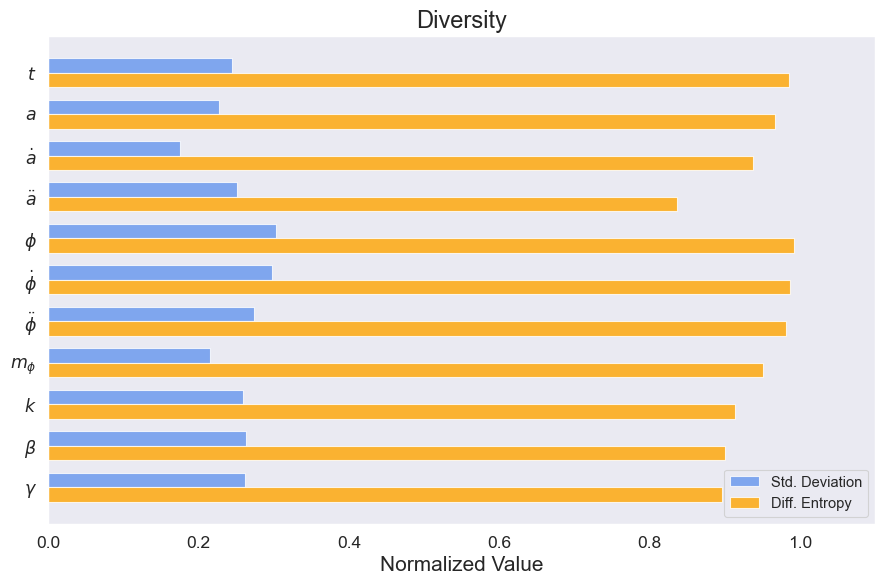


Mean bandwidth: 0.2503
Stdev of isotropic ensemble: 1.0000
Stdev of Resonance Intensity: 0.8600
Partition function: e^13.55



,efe_lhs,efe_rhs,kg_lhs,kg_rhs,acc_lhs,acc_rhs,rho_total,P_total,action,rho_kinetic,rho_potential,omega,nec,H,t_si,a_si,adot_si,adoubledot_si,phi_si,phidot_si,phidoubledot_si,mass_si,k,beta,gamma,sigma_q,intensity,probability,tension,intensity_analytic,probability_analytic,species,regime
0,7.797548e+02,7.797548e+02,2.542141e+38,2.542141e+38,7.797548e+02,7.797548e+02,1.253358e+29,-1.253358e+29,-6.858731e+57,3.427404e-28,1.253358e+29,-1.0,0.000000e+00,-8.594175e-07,2.265466e+08,6.227834e+06,-5.352309e+00,4.856183e+09,-8.862308e+07,-1.013541e-05,4.238827e+38,2.343991e-36,0.336504,0.599728,0.718804,0.262261,2.233458,-11.320079,3.019807e-14,2.518513,-11.035024,Dark Energy,Canonical
1,5.349036e-12,5.349036e-12,-2.067764e+58,-2.067764e+58,5.349036e-12,5.349036e-12,8.597904e+14,-8.597904e+14,-8.979081e+13,1.195837e-102,8.597904e+14,-1.0,0.000000e+00,1.028882e-34,1.293351e-42,4.322227e+13,4.447059e-21,2.311975e+02,7.474170e-27,7.956728e-43,-6.090131e+58,3.732298e-09,0.111186,0.339527,0.273436,0.208236,4.770785,-8.782752,3.197442e-14,4.554477,-8.999060,Dark Energy,Canonical
2,-2.108883e+31,-2.108883e+31,1.791240e+35,1.791240e+35,4.217766e+31,4.217766e+31,-3.389765e+57,-3.389765e+57,-1.608922e+30,-3.389765e+57,1.703701e-07,1.0,-6.779530e+57,1.845815e-02,2.390887e-06,5.833584e-08,1.076772e-09,2.460469e+24,-1.709664e-25,-1.883634e+38,-3.094027e-46,2.298005e-21,-0.798513,-0.017173,0.273156,0.265173,2.111998,-11.441539,2.842171e-14,2.156229,-11.397308,Exotic,Hybrid
3,1.947682e+45,1.947682e+45,1.173398e+14,1.173398e+14,-3.895363e+45,-3.895363e+45,3.130654e+71,3.130654e+71,1.675083e+41,3.130654e+71,5.975396e-24,1.0,6.261308e+71,-1.837121e-31,2.179103e+13,2.906528e-15,-5.339644e-46,-1.132198e+31,-9.153614e-21,-2.643139e+44,1.792530e-21,1.956629e-34,0.183074,0.805501,0.461005,0.282019,1.434468,-12.119069,2.842171e-14,1.396009,-12.157528,Stiff,Canonical
4,-1.561267e+27,-1.561267e+27,1.446576e+19,1.446576e+19,3.122535e+27,3.122535e+27,-2.509542e+53,-2.509542e+53,-1.062682e+08,-2.509542e+53,1.361367e+08,1.0,-5.019083e+53,3.738641e-17,3.475809e-29,2.301005e-06,8.602631e-23,7.184969e+21,-1.691630e+06,-3.497515e+35,1.466667e-39,4.608211e-45,-0.091975,-0.368762,0.554422,0.241793,3.127307,-10.426230,7.105427e-15,2.983475,-10.570062,Exotic,Hybrid


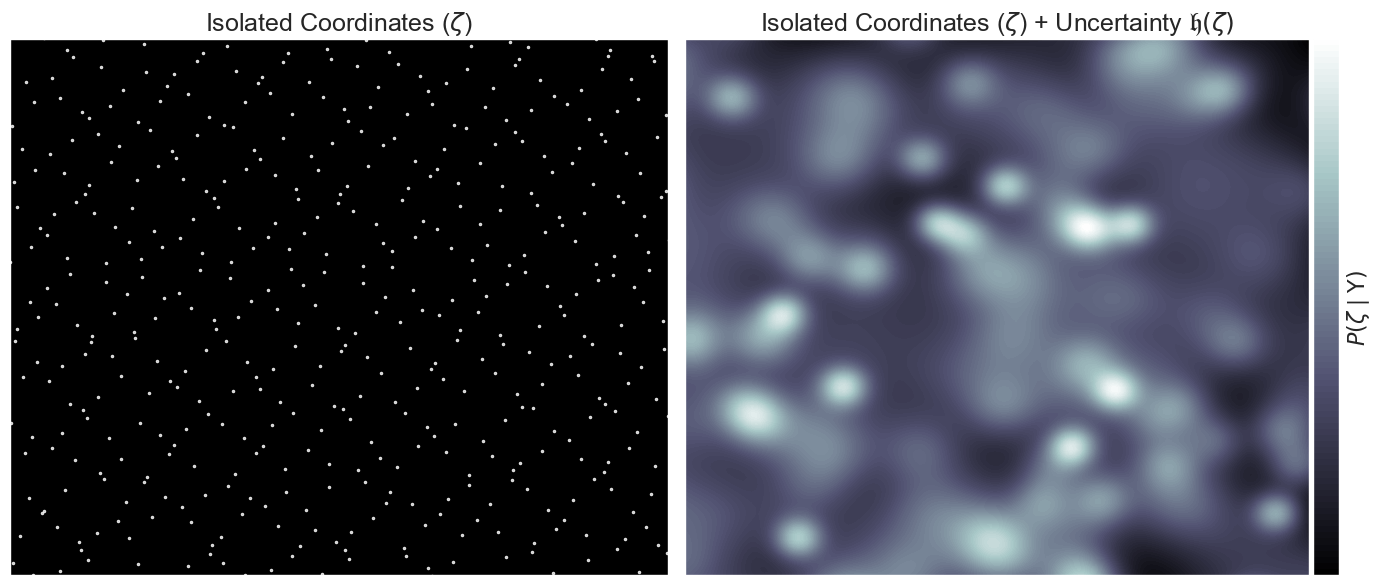

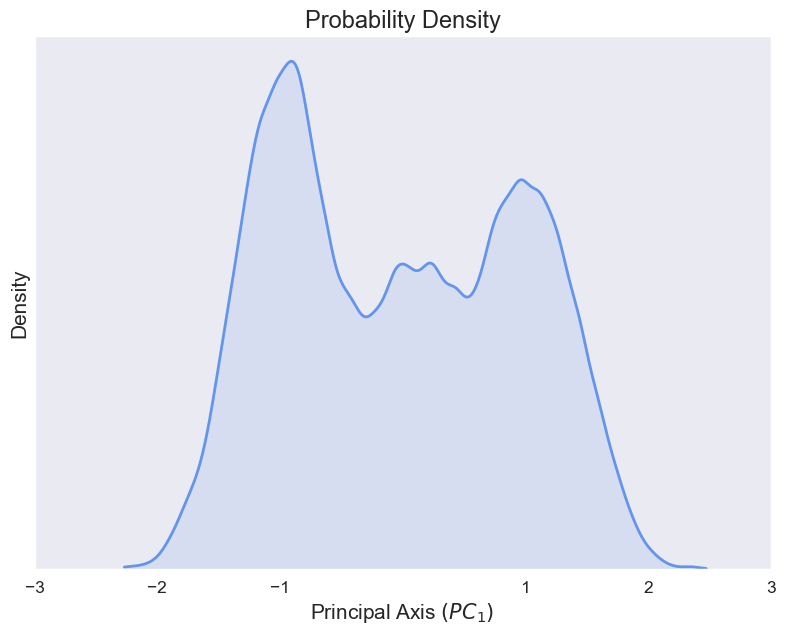

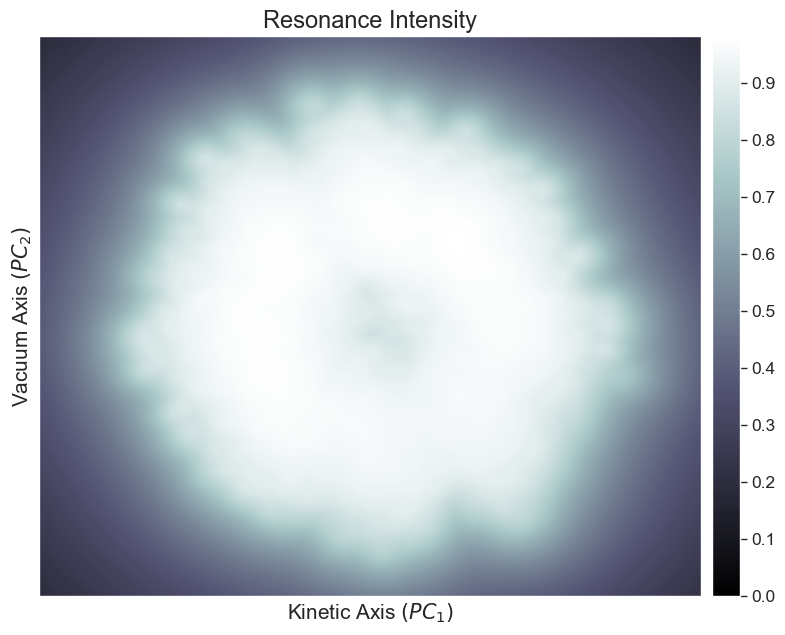


Peak indices: [147 268 349]
Peak x-coordinates: [-0.9036694   0.21947201  0.971327  ]
Peak probabilities: [1.         0.60251733 0.76662008]

Species composition at peak -0.904:
species
Stiff                232
Dark Energy           82
Positive Pressure      1
Name: count, dtype: int64

Species composition at peak 0.219:
species
Dark Energy    172
Exotic           2
Name: count, dtype: int64

Species composition at peak 0.971:
species
Exotic               124
Dark Energy          118
Negative Pressure      1
Name: count, dtype: int64

PCA Loadings:
|              |    PC1 |
|:-------------|-------:|
| t            |  0.011 |
| a            | -0.019 |
| adot         | -0.011 |
| adoubledot   |  0.657 |
| phi          | -0.01  |
| phidot       |  0.018 |
| phidoubledot |  0     |
| mass_phi     | -0.012 |
| k            | -0.295 |
| beta         | -0.639 |
| gamma        |  0.269 |
|              |    PC1 |    PC2 |
|:-------------|-------:|-------:|
| t            |  0.011 | -0.037 |
|

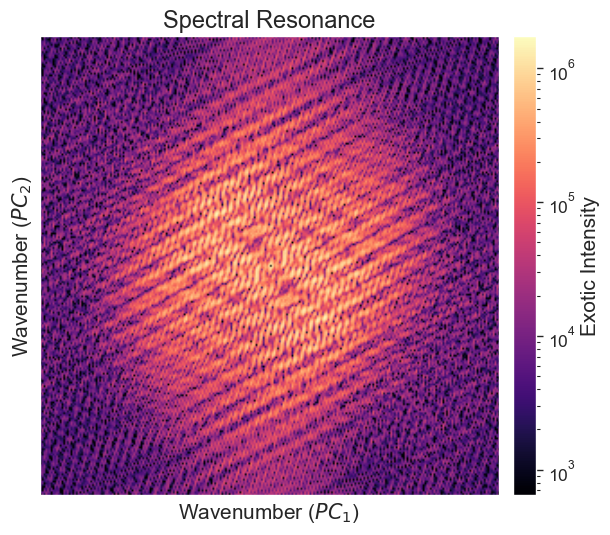

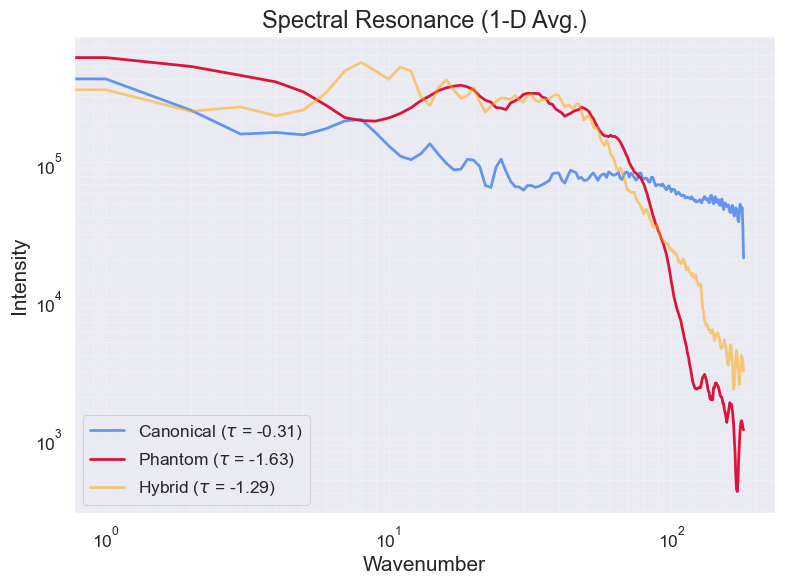

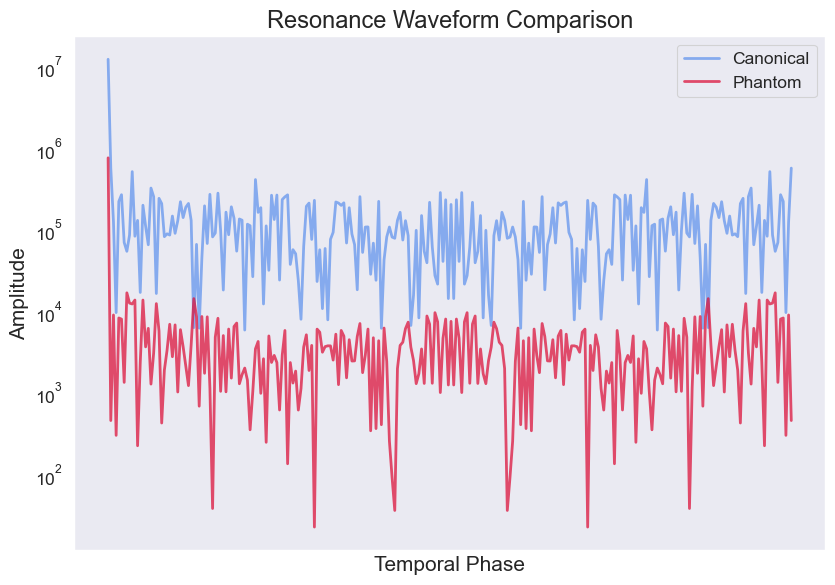

In [5]:
##### load and isotropize data #####
# load and clean
history_path = 'spacetime_ensemble.csv'

ensemble_exponents = pd.read_csv(history_path)
ensemble_exponents = ensemble_exponents.drop_duplicates()
ensemble_exponents = ensemble_exponents[ensemble_exponents['fitness'] <= hbar/2].drop(['fitness'],axis=1)

### diversity metrics
os.makedirs('plots', exist_ok=True) # to store plots if uncommented
diversity_results = diversity_statistics(ensemble_exponents) # run before KDE to feed entropy into bandwidths
norm_entropies = diversity_results['diff_entropies']

### isotropize ensemble
ensemble_iso, iso_params = hdim.isotropize(ensemble_exponents)
ensemble_si_vals = evaluate_ensemble(ensemble_exponents)
sigma_q_ensemble = quantum_bandwidth(ensemble_si_vals['t_si'], ensemble_si_vals['action'], iso_params['W_zca'], norm_entropies)

### analyze ensemble
ensemble_intensities = hdim.lorentzian(ensemble_iso, sigma_q_ensemble, ensemble_iso, eff_dim=11, verbose=False)
log_Z_partition = logsumexp(ensemble_intensities)

##### save topography parameters #####
np.savez_compressed('spacetime_data.npz', 
                    ensemble=ensemble_iso,
                    norm_entropies=norm_entropies,
                    iso_params=iso_params,
                    log_Z_partition=log_Z_partition)
archive = np.load('spacetime_data.npz', allow_pickle=True)

# extract for use
ensemble_iso = archive['ensemble']
iso_params = archive['iso_params'].item()


#### topography assessment #####
df_physics = analyze_coordinate(ensemble_exponents)
print(f'\nMean bandwidth: {np.mean(sigma_q_ensemble):.4f}')
print(f'Stdev of isotropic ensemble: {np.std(ensemble_iso):.4f}')
print(f'Stdev of Resonance Intensity: {np.std(ensemble_intensities):.4f}')
print(f'Partition function: e^{log_Z_partition:.4g}\n')
display(df_physics.head(5))

### plots
plot_concept(seed=2) # conceptual visualization
pca1d, pca2d, prob_1d, res_2d = pca_kde() # principal axes
spectral_analysis(ensemble_exponents, metric='nec') # spectral decomposition

## Analysis
- Numerical analysis of ensemble & probabilities


- Regime Distribution
Regime | Frequency % | Probability %
----------------------------------------------------
Canonical | 32.24% | 34.97%
Hybrid | 50.50% | 50.43%
Phantom | 17.26% | 14.60%




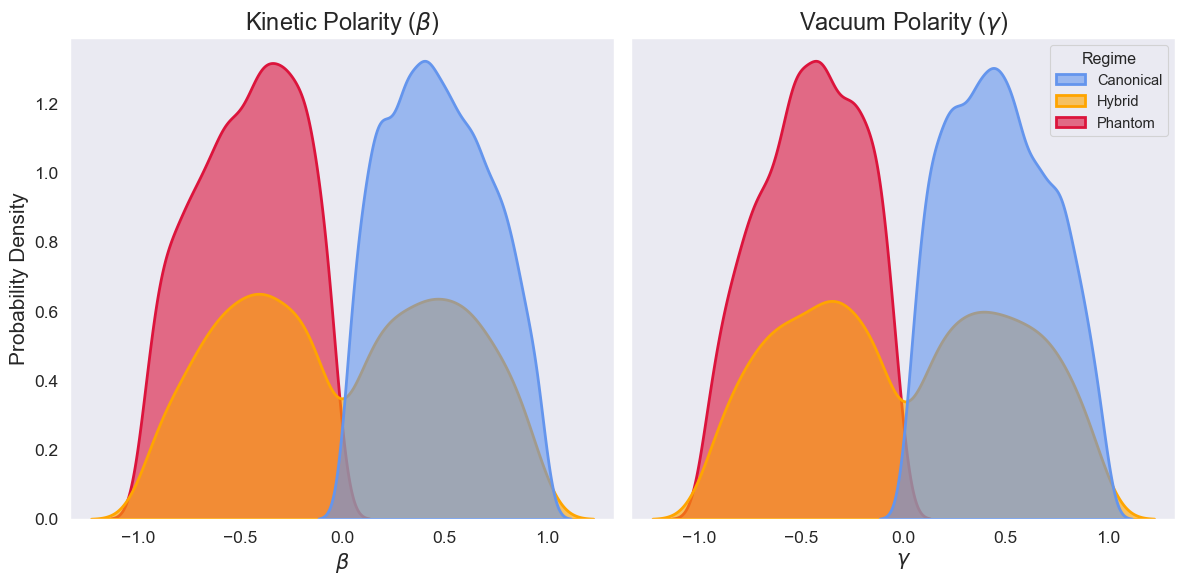


- Topography Analysis
Species | Frequency % | Probability %
---------------------------------------------------------------------------
Dark Energy | 44.87% | 48.35%
Stiff | 33.54% | 34.31%
Exotic | 21.16% | 16.55%
Negative Pressure | 0.15% | 0.34%
Superluminal | 0.12% | 0.22%
Positive Pressure | 0.14% | 0.22%
Phantom | 0.02% | 0.02%

\begin{table}
\caption{Ensemble Physical Statistics}
\label{tab:physical_statistics}
\begin{tabular}{lr|rr|rr}
\toprule
 & Median & Mean & Stdev. & Min. & Max. \\
\midrule
$t$ & 2.55e-13 & 1.39e+15 & 2.22e+16 & 5.94e-44 & 8.42e+17 \\
$a$ & 1.98e+03 & 3.39e+24 & 3.71e+25 & 1.64e-35 & 9.96e+26 \\
$\dot{a}$ & 5.19e-53 & 6.81e+62 & 1.24e+65 & -2.30e+63 & 2.26e+67 \\
$\ddot{a}$ & -1.37e-09 & 3.81e+104 & 6.94e+106 & -2.55e+103 & 1.26e+109 \\
$\phi$ & -3.12e-33 & 3.44e+17 & 4.69e+20 & -9.53e+21 & 9.68e+21 \\
$\dot{\phi}$ & 7.41e-53 & -1.50e+60 & 1.04e+63 & -6.91e+64 & 6.78e+64 \\
$\ddot{\phi}$ & 4.64e-71 & 6.27e+101 & 1.30e+104 & -5.82e+105 & 2.26e+106 \\
$m_{\

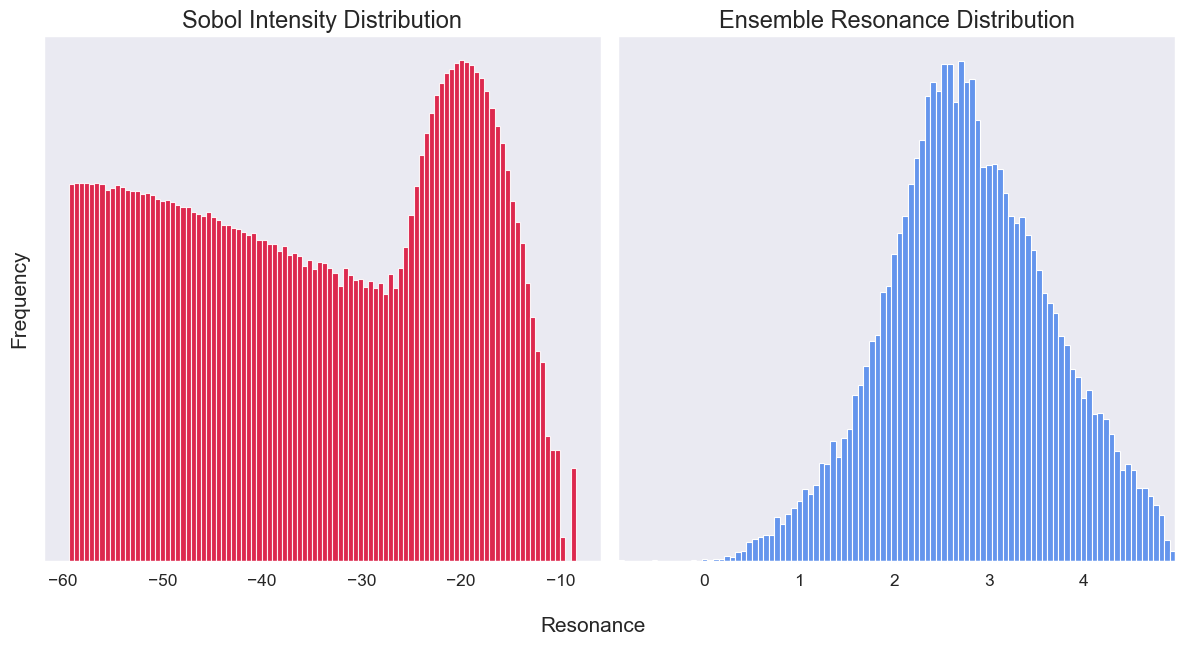

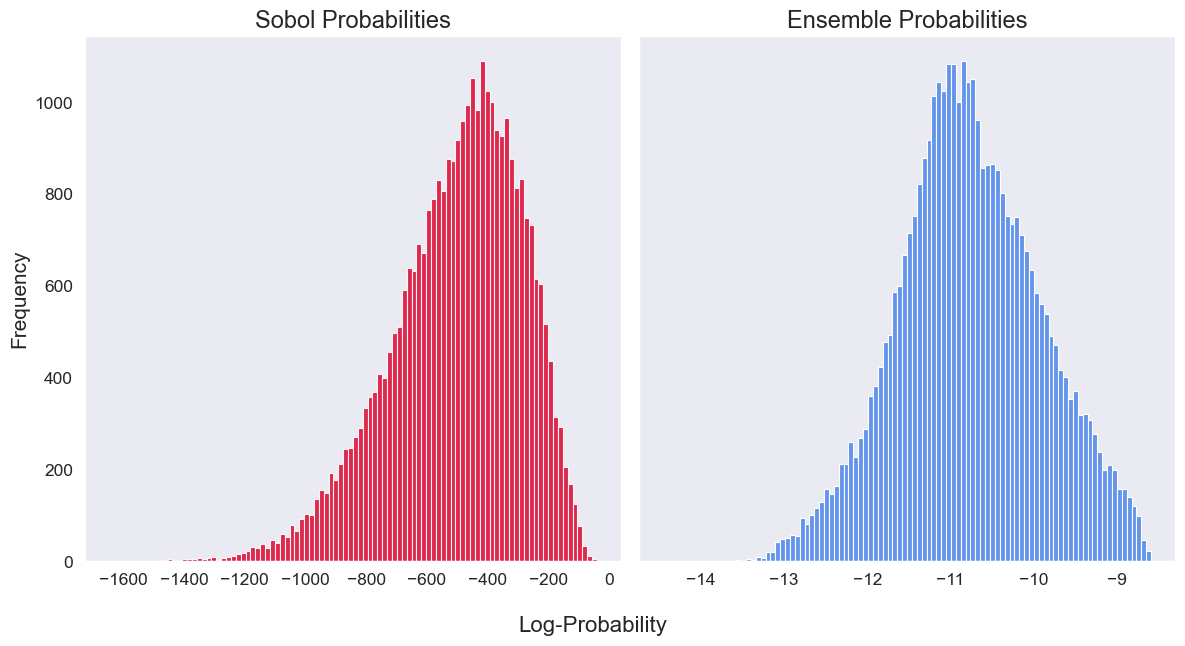

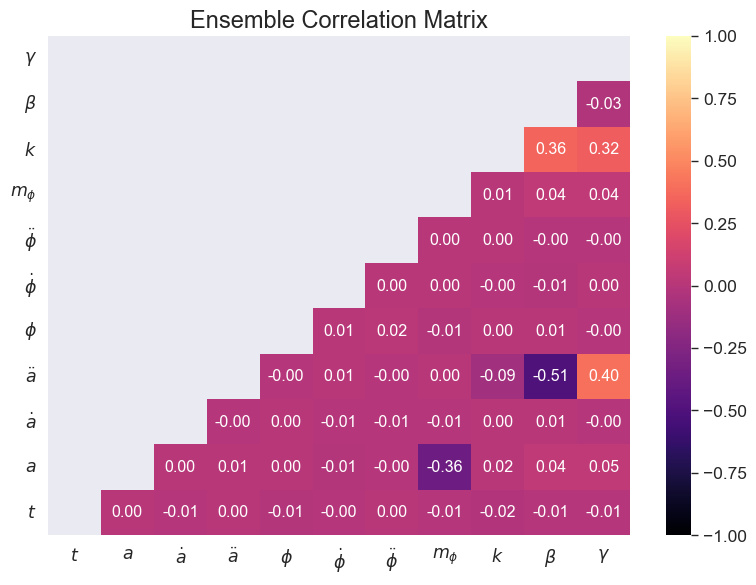

\begin{table}
\caption{Ensemble Covariance Matrix}
\label{tab:covariance}
\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & $t$ & $a$ & $\dot{a}$ & $\ddot{a}$ & $\phi$ & $\dot{\phi}$ & $\ddot{\phi}$ & $m_{\phi}$ & $k$ & $\beta$ & $\gamma$ \\
\midrule
$t$ & 223.9 & 0.6 & -3.8 & 2.3 & -6.7 & -2.6 & 5.9 & -1.2 & -0.1 & -0.0 & -0.1 \\
$a$ & 0.6 & 197.8 & 2.4 & 7.1 & 2.1 & -8.9 & -1.0 & -66.6 & 0.1 & 0.3 & 0.3 \\
$\dot{a}$ & -3.8 & 2.4 & 1862.0 & -9.3 & 5.9 & -15.8 & -26.8 & -3.4 & 0.1 & 0.1 & -0.1 \\
$\ddot{a}$ & 2.3 & 7.1 & -9.3 & 8496.8 & -8.4 & 57.6 & -9.0 & 4.6 & -4.5 & -24.5 & 19.4 \\
$\phi$ & -6.7 & 2.1 & 5.9 & -8.4 & 1150.9 & 27.6 & 60.4 & -4.0 & 0.0 & 0.1 & -0.0 \\
$\dot{\phi}$ & -2.6 & -8.9 & -15.8 & 57.6 & 27.6 & 4922.0 & 14.4 & 2.5 & -0.2 & -0.3 & 0.0 \\
$\ddot{\phi}$ & 5.9 & -1.0 & -26.8 & -9.0 & 60.4 & 14.4 & 9543.5 & 2.8 & 0.1 & -0.1 & -0.1 \\
$m_{\phi}$ & -1.2 & -66.6 & -3.4 & 4.6 & -4.0 & 2.5 & 2.8 & 176.9 & 0.0 & 0.3 & 0.3 \\
$k$ & -0.1 & 0.1 & 0.1 & -4.5 & 0.0 & -0.2 & 0.1 & 0.0 

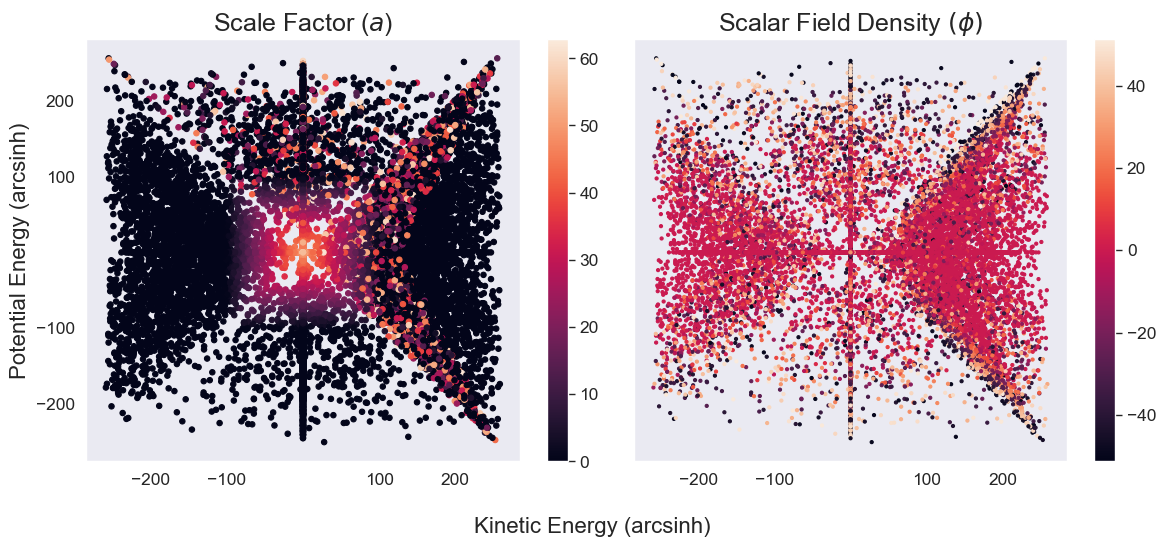


Encoded ensemble:
Stats:
- Norm. Stdev: 13.8% ± 0.0%
- Entropy: 85.1% ± 5.0%
- Span: 621

Principal Axes:
| Dimension    |    PC1 |    PC2 |   Magnitude |
|:-------------|-------:|-------:|------------:|
| gamma        |  0.269 |  0.683 |       0.734 |
| k            | -0.295 |  0.642 |       0.706 |
| adoubledot   |  0.657 |  0.232 |       0.696 |
| beta         | -0.639 |  0.226 |       0.678 |
| a            | -0.019 |  0.125 |       0.126 |
| t            |  0.011 | -0.037 |       0.038 |
| phidot       |  0.018 | -0.007 |       0.02  |
| mass_phi     | -0.012 | -0.005 |       0.013 |
| phi          | -0.01  |  0.007 |       0.012 |
| adot         | -0.011 |  0.002 |       0.011 |
| phidoubledot |  0     | -0.002 |       0.002 |
|                |   PC1 |   PC2 |   Total |
|:---------------|------:|------:|--------:|
| Explained Var. | 0.154 |  0.13 |   0.285 |



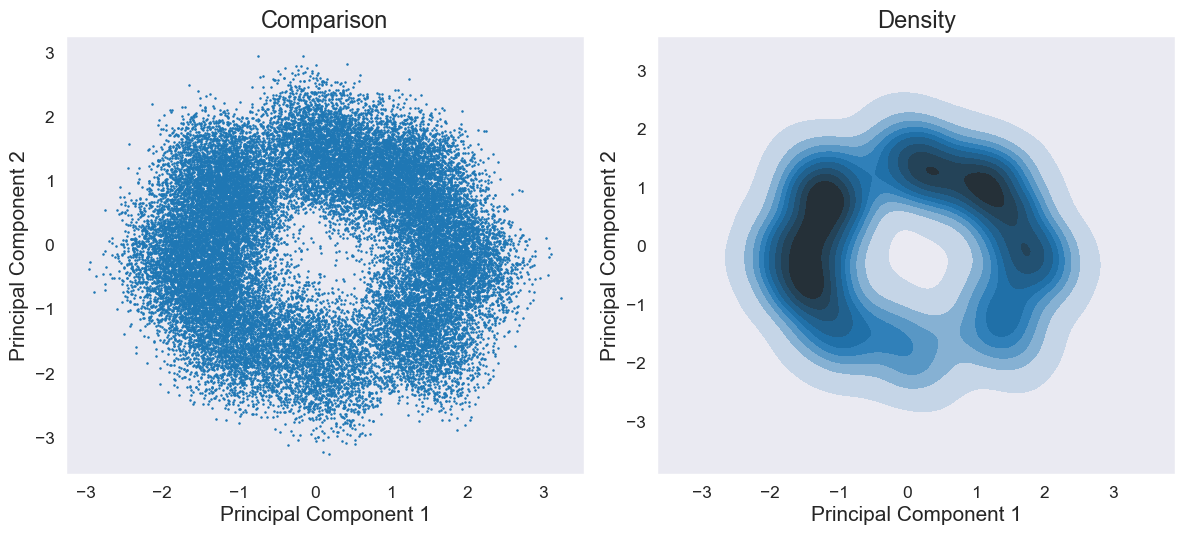

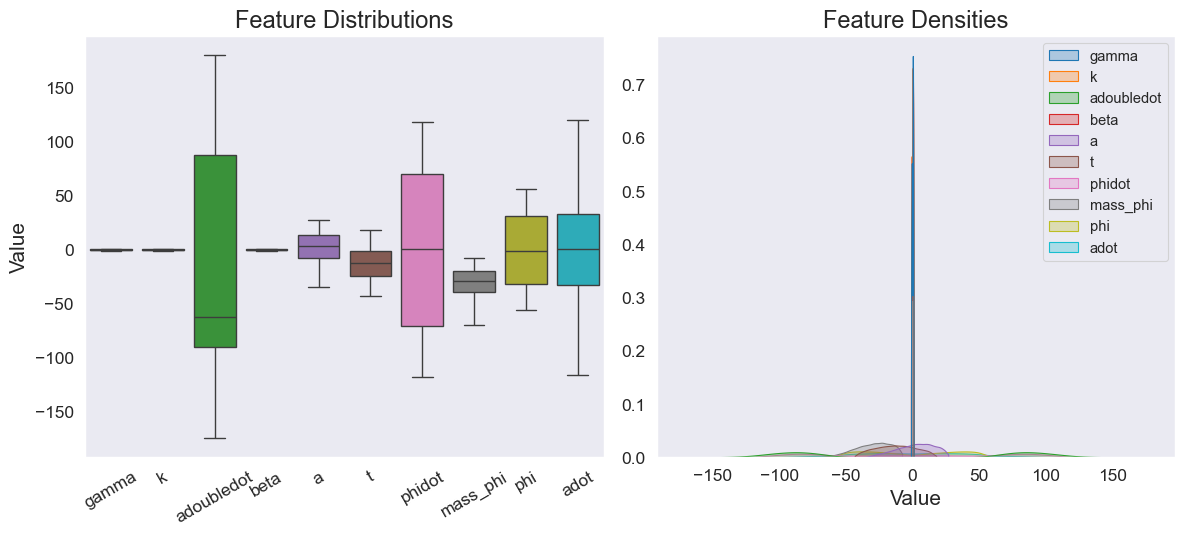

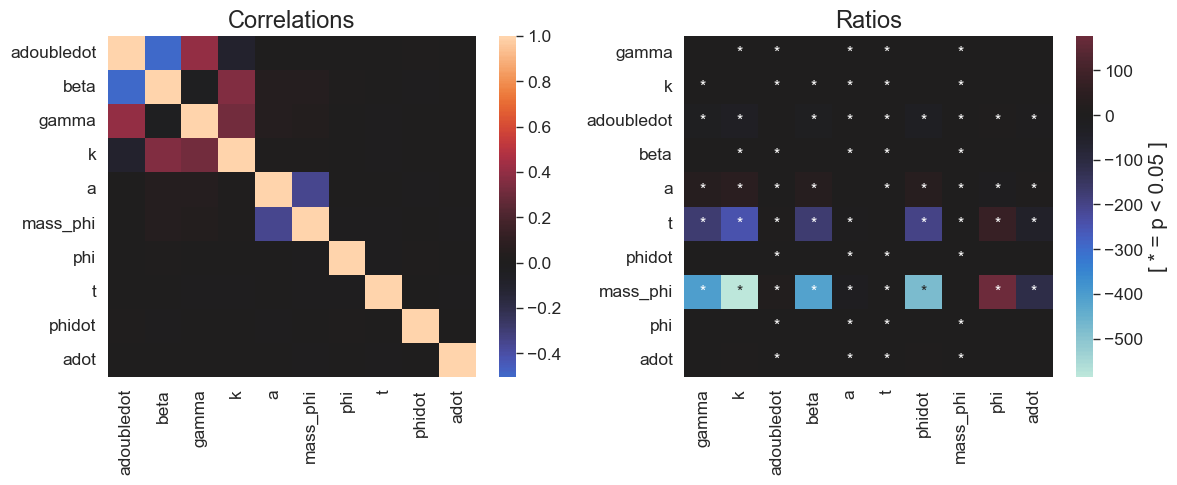

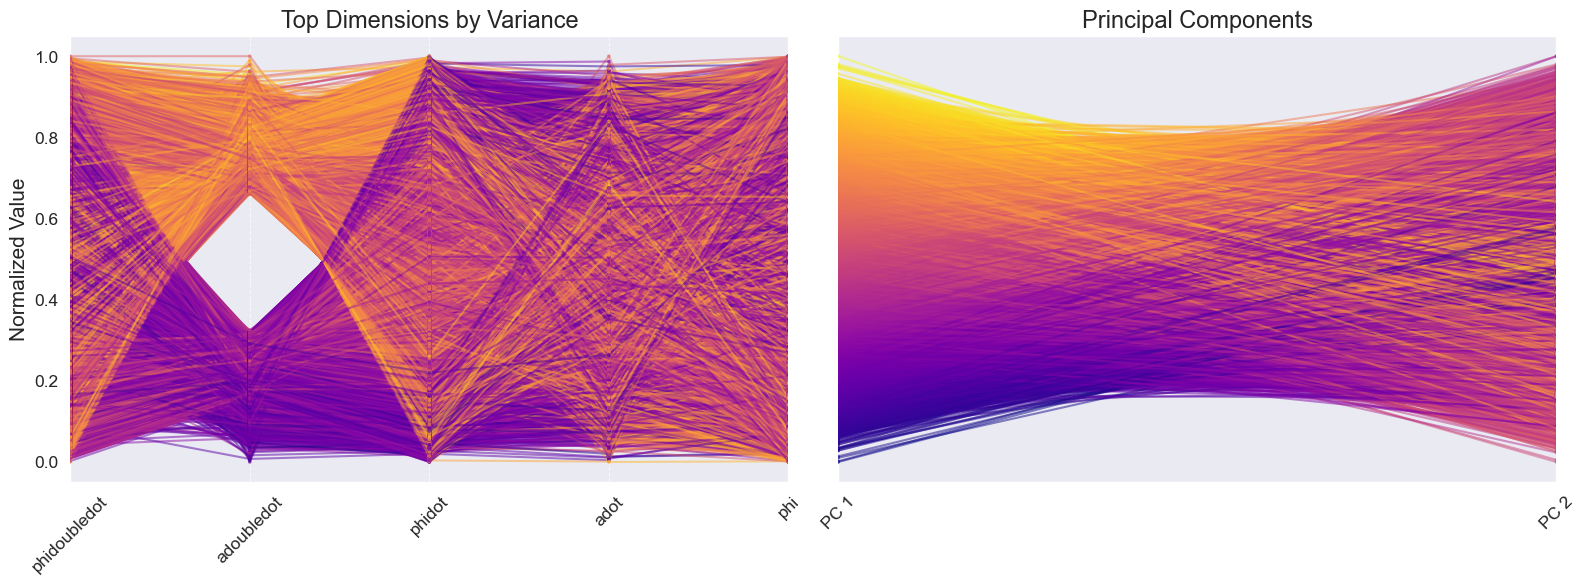

Generating Sobol samples (N=1,024, D=11).
Analyzing sensitivities.

Run time: 2.34s


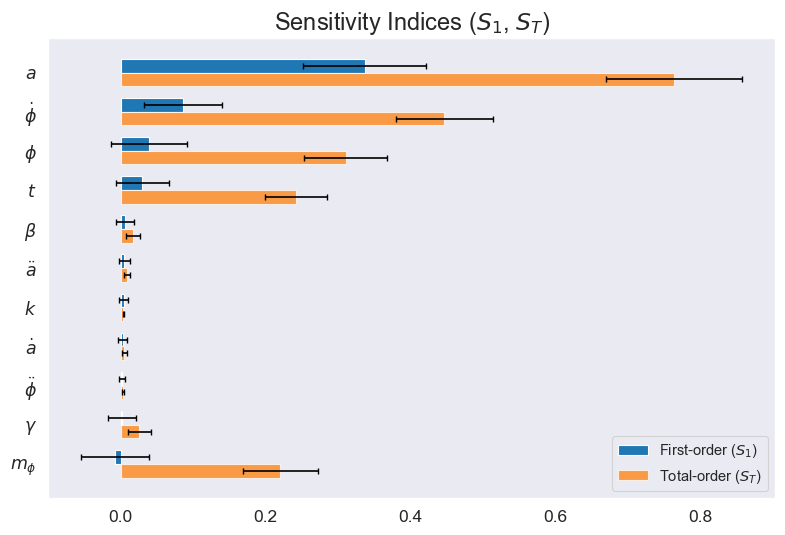

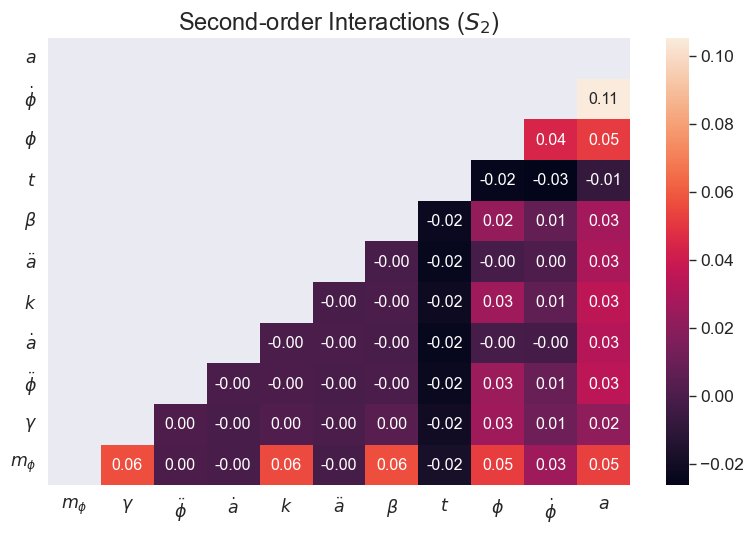

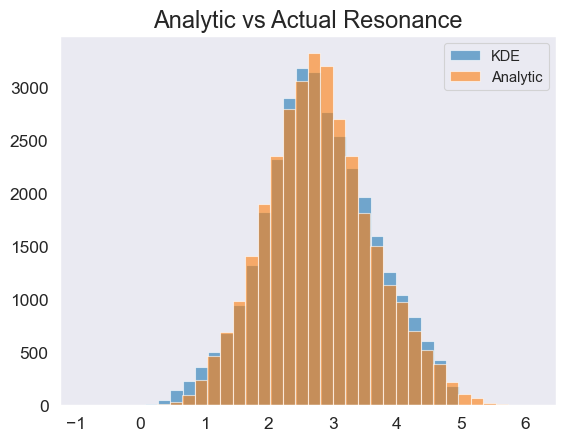

In [6]:
## analyze topography
physical_stats = physical_statistics(ensemble_exponents)
sobol_distributions() # compare resonance of a sobol sequence
covariance_analysis(ensemble_exponents)
plot_energy_scatter()
print('\nEncoded ensemble:')
hdim.analyze(ensemble_exponents)

# sensitivity analysis
n_sensitivity_samples = 2**13 if plot_resolution == 'high' else 2**10
bounds_iso_min = ensemble_iso.min(axis=0)
bounds_iso_max = ensemble_iso.max(axis=0)
bounds_iso = list(zip(bounds_iso_min, bounds_iso_max))
sens = hdim.sensitivity(
                    sensitivity_lorentzian_wrapper, kwargs={'ensemble': ensemble_iso}, 
                    bounds=bounds_iso, param_names=formatted_labels, n_samples=n_sensitivity_samples, 
                    calc_second_order=True, num_to_plot=n_dim, log_scale=False, verbose=True)

# resonance approximation
df_physics = analyze_coordinate(ensemble_exponents)
plt.hist(df_physics['intensity'],bins=30,alpha=0.6,label='KDE')
plt.hist(df_physics['intensity_analytic'],bins=30,alpha=0.6,label='Analytic')
plt.title('Analytic vs Actual Resonance')
plt.legend()
plt.show()

## Topographic Evolution
- Coordinates tend towards higher probability (via probability gradients)
- Evolution evaluated via 4th order Runge-kutta

Average coordinate: [ 1.39149243e+015  3.39364534e+024  6.81470530e+062  3.81451355e+104
  3.43977052e+017 -1.50261097e+060  6.26693217e+101  8.32964997e-011
  5.12883832e-002  7.30525719e-002  7.45577785e-002]

Most probable coordinate: [7.176194484955517e-44 1.2063703502722297e+25 1.0109703648161905e+42
 -1.6944399840495798e+59 685.2512760500425 6.6357140065732875e+38
 5.3006854503718635e-30 5.730349086617178e-25 -0.6700402822853828
 0.4608172196638904 -0.4703843546058143 'Stiff']


Zeta stats:


,Median,Expected,Mean,Max
t,2.551642e-13,5.280067e+14,1.391492e+15,8.421861e+17
a,1.984498e+03,5.459399e+24,3.393645e+24,9.961722e+26
adot,5.194707e-53,2.383528e+63,6.814705e+62,2.256393e+67
adoubledot,-1.368808e-09,1.334281e+105,3.814514e+104,1.263120e+109
phi,-3.124410e-33,3.680924e+18,3.439771e+17,9.679716e+21
phidot,7.412135e-53,1.212983e+60,-1.502611e+60,6.780381e+64
phidoubledot,4.635550e-71,2.459408e+102,6.266932e+101,2.262065e+106
mass_phi,2.137476e-29,8.328887e-11,8.329650e-11,2.099503e-08
k,1.304775e-01,5.453879e-02,5.128838e-02,9.997369e-01
beta,1.634696e-01,1.019921e-01,7.305257e-02,9.995795e-01


Evaluating topographic trajectory.
Progress: 0% (dt = 0.001)
Progress: 10% (dt = 0.001)
Progress: 20% (dt = 0.001)
Progress: 30% (dt = 0.001)
Progress: 40% (dt = 0.001)
Progress: 50% (dt = 0.001)
Progress: 60% (dt = 0.001)
Progress: 70% (dt = 0.001)
Progress: 80% (dt = 0.001)
Progress: 90% (dt = 0.001)


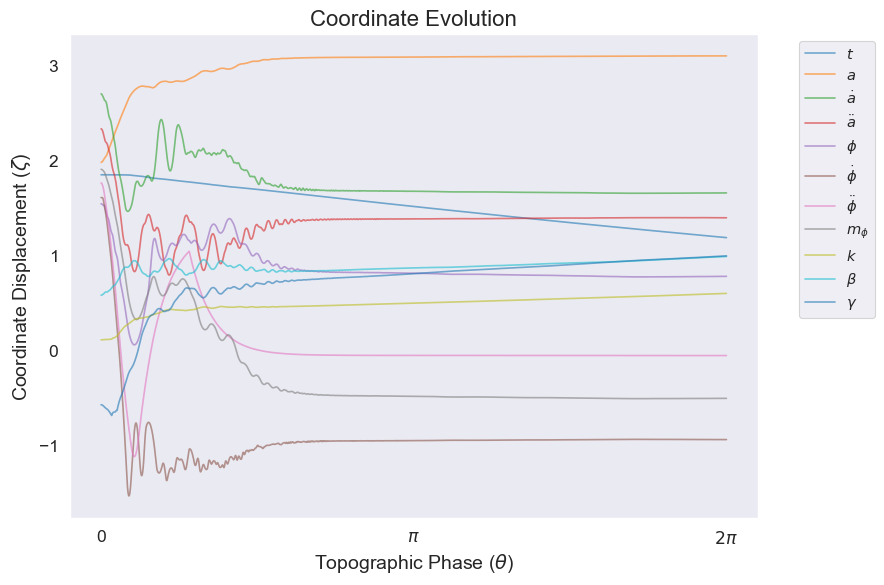

In [7]:
def topographic_evolution(zeta_exp_start, analytic=True,
                           t_max=2*np.pi, initial_dt=1e-3, tolerance=1e-2,
                           verbose=True):
    '''
    Objective:
        - Evaluate the trajectory of a coordinate due to probability gradients.
        - Solves the equation of motion numerically via 4th order Runge-Kutta integration.
    
    Inputs:
        - zeta_exp_start: Zeta coordinate to evaluate (bipolar-encoded).
        - t_max: Maximum time (end time).
        - initial_dt: Initial timestep.
        - tolerance: Error tolerance for adaptive timestep scaling.
        
    Outputs:
        - time_history: Time values of the coordinate evolution.
        - coordinate_history: Zeta history over the evolution.
    '''
    
    # initialize in isotropic space
    z_curr_iso = isotropize_zeta(zeta_exp_start).flatten()
    v_curr_iso = np.zeros(11) 
    
    t_curr = 0.0
    dt = initial_dt
    
    # helper function for a single RK4 step
    def rk4_step(z, v, step_dt):
        k1_v = equation_of_motion(z, v, analytic=analytic)
        k1_x = v
        
        k2_v = equation_of_motion(z + 0.5 * step_dt * k1_x, v + 0.5 * step_dt * k1_v, analytic=analytic)
        k2_x = v + 0.5 * step_dt * k1_v
        
        k3_v = equation_of_motion(z + 0.5 * step_dt * k2_x, v + 0.5 * step_dt * k2_v, analytic=analytic)
        k3_x = v + 0.5 * step_dt * k2_v
        
        k4_v = equation_of_motion(z + step_dt * k3_x, v + step_dt * k3_v, analytic=analytic)
        k4_x = v + step_dt * k3_v
        
        v_next = v + (step_dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
        z_next = z + (step_dt / 6.0) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
        return z_next, v_next
        
    ### evaluate trajectory (isotropic space)
    print('Evaluating topographic trajectory.')
    coordinate_history = [z_curr_iso.copy()]
    velocity_history = [v_curr_iso.copy()]
    time_history = [t_curr]
    last_decile = -1
    while t_curr < t_max:
        current_decile = int((t_curr / t_max) * 10)
        if current_decile > last_decile:
            print(f'Progress: {current_decile * 10}% (dt = {dt:.3})')
            last_decile = current_decile
            
        # RK4 steps
        z1, v1 = rk4_step(z_curr_iso, v_curr_iso, dt)
        zh, vh = rk4_step(z_curr_iso, v_curr_iso, dt / 2.0)
        z2, v2 = rk4_step(zh, vh, dt / 2.0)
        
        # stability check
        error = np.max(np.abs(z2 - z1)) / 15
        if np.isnan(error) or error > tolerance or np.any(np.abs(z2) > 10.0):
            dt *= 0.1
            if dt < 1e-9:
                break # prevent infinite loops
            
        else:
        # update trajectory
            z_curr_iso, v_curr_iso = z2, v2
            t_curr += dt
            coordinate_history.append(z_curr_iso.copy())
            velocity_history.append(v_curr_iso.copy())
            time_history.append(t_curr)
        if error < tolerance / 10.0:
            dt = np.clip(dt * 1.5, 1e-9, 1e-3) # cap max dt at 0.001

    isotropic_coordinates = np.array(coordinate_history)
    if verbose:
        plt.figure(figsize=(9, 6))
        for d in range(n_dim):
            sns.lineplot(x=time_history, y=isotropic_coordinates[:, d], alpha=0.6, label=list(plot_label_map.values())[d])
            
        plt.title('Coordinate Evolution', fontsize=16)
        plt.xlabel(r'Topographic Phase ($\theta$)', fontsize=14)
        plt.ylabel(r'Coordinate Displacement ($\zeta$)', fontsize=14)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(False)
        if t_max == 4*np.pi:
            plt.xticks([0,2*np.pi,4*np.pi], [0, r'$2\pi$', r'$4\pi$'])
        elif t_max == 2*np.pi:
            plt.xticks([0,np.pi,2*np.pi], [0, r'$\pi$', r'$2\pi$'])
        
        plt.tight_layout()
        # if plot_resolution == 'high':
        # plt.savefig('plots/cosmic_oscillation.png')
        plt.show()
    return np.array(time_history), isotropic_coordinates, np.array(velocity_history)

### zeta test coordinates (SI values)
zeta_0 = expectation_value(df_physics, verbose=False)
zeta_median = np.median(df_physics[zeta_order_si],axis=0)
zeta_mean = np.mean(df_physics[zeta_order_si],axis=0)
zeta_stdev = np.std(df_physics[zeta_order_si],axis=0)
zeta_max = np.max(df_physics[zeta_order_si],axis=0)
zeta_probable = df_physics[df_physics['probability'] == df_physics['probability'].max()][zeta_order_si+['species']]
print(f'Average coordinate: {zeta_mean.values.flatten()}\n')
print(f'Most probable coordinate: {zeta_probable.values.flatten()}\n\n')

print('Zeta stats:')
zeta_stats = pd.DataFrame([zeta_median,zeta_0,zeta_mean,zeta_max],columns=zeta_order,index=['Median','Expected','Mean','Max']).T
display(zeta_stats)

### execution
zeta_0_encoded = encode_zeta(zeta_0) # encode to bipolar-logarithmic space
time_history, iso_trajectory, iso_velocities = topographic_evolution(zeta_0_encoded, analytic=True,
                                                                     t_max=2*np.pi, initial_dt=1e-3, tolerance=1e-3)


## Exotic Probabilities
- Resonant: KDE evaluated in the canonical phase $(\beta,\gamma)$=(1,1)
- Fluctuation: Fluctuations into the canonical phase $(\beta,\gamma)$=(1,1)

- Exotic canonical-repolarized probability:
Asymmetric Deviation:
- Median: -324
- Superscript (+): 179
- Subscript (-): -323

Probability is negligible below: e^-141
Proportion resonating above existence threshold: 0.153

- Exotic optimal-repolarized probability:
Asymmetric Deviation:
- Median: -30
- Superscript (+): 8
- Subscript (-): -169
Median vs Random exotic fluid:


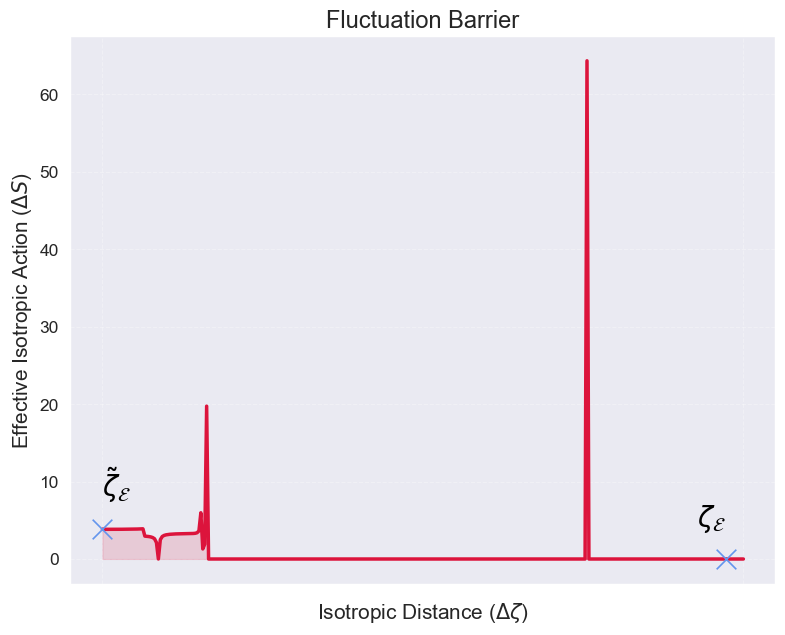


Probability gradient phase map:


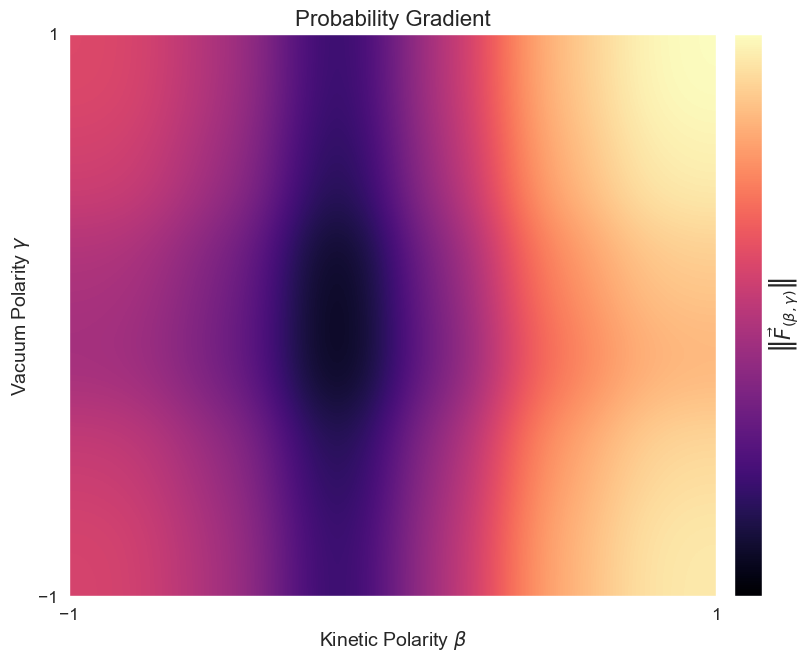


Fluctuation probability into canonical phase:
Asymmetric Deviation:
- Median: -214
- Superscript (+): 57
- Subscript (-): -86

- Proportion resonating above existence threshold: 0.153
- Proportion fluctuating into our universe at least once: 0.103

Fluctuating and resonating:
Asymmetric Deviation:
- Median: -568
- Superscript (+): 224
- Subscript (-): -372
Resonance and fluctuation R^2: 0.0008

- Proportion both fluctuating and resonating: 0.034
- Expected Probability: -144



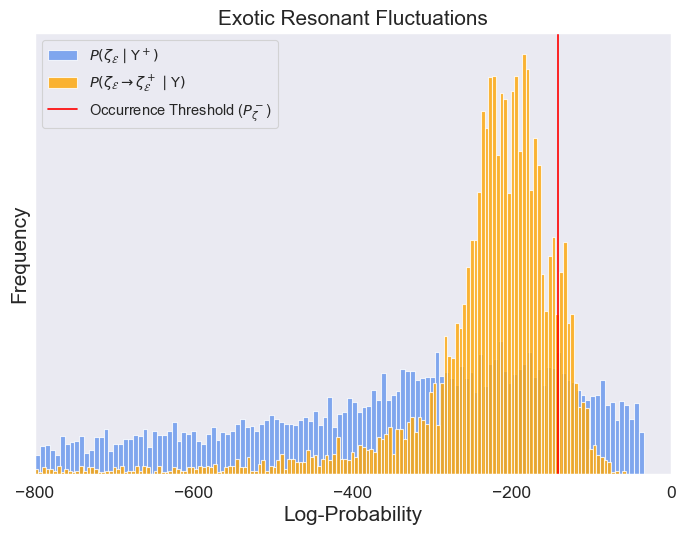

In [8]:
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

################# repolarized metrics #################
test_species = 'Exotic'
exotic_species_raw = df_physics[df_physics['species']==test_species]
exotic_species = encode_zeta(exotic_species_raw[zeta_order_si])
exotics_canonical = repolarize_zeta(exotic_species, 1.0, 1.0)
repol_probs = exotics_canonical['probability'].values
print('- Exotic canonical-repolarized probability:')
asymmetric_deviation(repol_probs)

##### minimum probability to exist at least once
max_time_quanta = 10**(bounds[0][1]-bounds[0][0])
min_proba_existing = -np.log(max_time_quanta)
print(f'\nProbability is negligible below: e^{min_proba_existing:.0f}')

# proportion resonating above minimum threshold to exist once
resonant_existing = (repol_probs >= min_proba_existing)  # (t_H / t_p)^-11
resonant_occurring = np.sum(resonant_existing) / len(exotic_species)
print(f'Proportion resonating above existence threshold: {resonant_occurring:.3f}')


# # ################# identify optimal exotic phase #################
# ##### long runtime:
# n_iter = 20 if plot_resolution == 'high' else 1
# print(f'\nFinding optimal phase for species {test_species}:')
# opt_phase, opt_phase_err = find_resonant_phase(test_species,n_iter=n_iter) 

# Optimal exotic phase: [-0.41599771  0.44801517] ± [0.00331006 0.00312693]
print('\n- Exotic optimal-repolarized probability:')
exotics_typical = repolarize_zeta(exotic_species, -0.5, 0.5) # using optimal phase (approx -0.5, 0.5)
asymmetric_deviation(exotics_typical['probability'].values)




################# fluctuation metrics #################
### exotic fluctuation comparison
print('Median vs Random exotic fluid:')
random.seed(6) # seed 6 visually best
exotic_median = np.array(np.median(exotic_species,axis=0)) # median exotic fluid
exotic_random = random.choice(exotic_species) # random exotic fluid
results = fluctuation_analysis(exotic_median, exotic_random, path_steps=333)

### plot exotic resonant force #####
print('\nProbability gradient phase map:')
plot_force_field(exotic_median)


# ##### long runtime takes a while to fluctuate them all:
# ################ ensemble exotic fluctuations into canonical phase #################
# print(f'\n- Fluctuating {len(exotic_species)} ensemble exotic fluid coordinates to canonical phase:')

# # collect probabilities for each coordinate in ensemble
# fluctuation_probs = []
# for i, zeta_w in enumerate(exotic_species):
#     if i % (len(exotic_species) // 10) == 0:
#         print(int(i / len(exotic_species) * 100), '%')
#     # set destination (canonical phase)
#     zeta_dest = zeta_w.copy()
#     zeta_dest[9], zeta_dest[10] = 1.0, 1.0  # set beta=1, gamma=1
    
#     # run analysis
#     fluc_stats = fluctuation_analysis(zeta_w, zeta_dest, verbose=False)
#     fluctuation_probs.append(fluc_stats['probability'])

# # save values to avoid having to re-run
# fluctuation_probs = np.array(fluctuation_probs)
# np.savetxt('fluctuation_probs.csv', fluctuation_probs, delimiter=',', fmt='%d')


### analyze fluctuation probs
print('\nFluctuation probability into canonical phase:')
fluctuation_probs = np.loadtxt('fluctuation_probs.csv', delimiter=',', dtype=float)
asymmetric_deviation(fluctuation_probs)

# identify states with probability below 1 occurence in hubble age
successful_fluctuations = (fluctuation_probs >= min_proba_existing)  # (t_H / t_p)

# ratio of successful occurrences
fluctuations_occurring = np.sum(successful_fluctuations) / len(exotic_species)
print(f'\n- Proportion resonating above existence threshold: {resonant_occurring:.3f}')
print(f'- Proportion fluctuating into our universe at least once: {fluctuations_occurring:.3f}')


################ resonant fluctuations
print('\nFluctuating and resonating:')
# distribution
joint_probs = repol_probs + fluctuation_probs # R^2 ~ 0
asymmetric_deviation(joint_probs)
expected_proba = logsumexp(joint_probs) - np.log(len(joint_probs)) # ln( sum(exp(x)) / N )

# r^2 between resonance and fluctuations
res_fluc_r2, res_fluc_pval = stats.pearsonr(repol_probs, fluctuation_probs)
print(f'Resonance and fluctuation R^2: {res_fluc_r2:.4f}')

# proportion
resonant_fluctuations = (fluctuation_probs >= min_proba_existing) & (repol_probs >= min_proba_existing)
resonant_fluctuations_proportion = np.sum(resonant_fluctuations) / len(exotic_species)
print(f'\n- Proportion both fluctuating and resonating: {resonant_fluctuations_proportion:.3f}')
print(f'- Expected Probability: {expected_proba:.0f}\n')

# plot overlap
fig, ax = plt.subplots(1, 1, figsize=(7,5.5))
ax.hist(repol_probs,alpha=0.8, bins=200, density=True, color='cornflowerblue', label=r'$P(\zeta_\mathcal{E} \mid \Upsilon^+)$')
ax.hist(fluctuation_probs[fluctuation_probs > -1000],alpha=0.8, bins=200, density=True, color='orange', label=r'$P(\zeta_\mathcal{E} \to \zeta_\mathcal{E}^+ \mid \Upsilon)$')
ax.axvline(min_proba_existing, color='red', label=r'Occurrence Threshold ($P^-_\zeta$)')
ax.set_title('Exotic Resonant Fluctuations', fontsize=15)
ax.set_ylabel('Frequency')
ax.set_xticks([-800,-600,-400,-200,0])
ax.set_yticks([])
ax.set_xlabel(r'Log-Probability')
ax.set_xlim([-800,0])
ax.legend()

plt.tight_layout()
# plt.savefig('plots/exotic_probabilities.png')
plt.show()



### Exotic canonical-repolarized probability:
# Asymmetric Deviation:
# - Median: -324
# - Superscript (+): 179
# - Subscript (-): -323

# - Exotic optimal-repolarized probability:
# Asymmetric Deviation:
# - Median: -30
# - Superscript (+): 8
# - Subscript (-): -169


### Exotic canonical-fluctuation probability:
# Asymmetric Deviation:
# - Median: -214
# - Superscript (+): 57
# - Subscript (-): -86

# - Proportion resonating above existence threshold: 0.153
# - Proportion fluctuating into our universe at least once: 0.103

### Fluctuating and resonating:
# Asymmetric Deviation:
# - Median: -568
# - Superscript (+): 224
# - Subscript (-): -372

# - Proportion both fluctuating and resonating: 0.034
# - Expected Probability: -144
# R^2: 0.0008

## Symbolic Regression (KDE Approximation)
- Uncomment to generate analytic expressions via genetic programming

In [9]:
# from gplearn.genetic import SymbolicRegressor
# from gplearn.functions import make_function
# from sklearn.metrics import r2_score, mean_absolute_error
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.linear_model import LinearRegression

# ### split data
# df_physics_clean = df_physics[df_physics['intensity'].between(df_physics['intensity'].quantile(0.05), 
#                                                               df_physics['intensity'].quantile(0.95))] # filter 2 stdevs for easier training
# y = df_physics_clean['intensity'].copy().values.reshape(-1,1)
# y_scaled = (y - y.mean())/y.std() # Z-scale resonance

# ### scale inputs
# X_raw = encode_zeta(df_physics_clean[zeta_order_si]) # ENCODED SI inputs
# X_scaled = X_raw / np.abs(X_raw).max(axis=0) # min-max scaling all variables

# # shapes for gplearn
# def _lorentzian(x):
#     return 1.0 / (1.0 + np.square(x))
# def _square(x):
#     return np.square(x)
# def _cube(x):
#     return np.power(x,3)
# def _quartic(x):
#     return np.power(x,4)
# def _abs(x):
#     return np.abs(x)
# def _sqrt(x):
#     return np.sqrt(np.abs(x))
# def _dw(x):
#     return np.square(np.square(x) - 1)

# # cconvert to gplearn function objects
# sqrt_func = make_function(function=_sqrt, name='sqrt', arity=1)
# square_func = make_function(function=_square, name='sq', arity=1)
# cube_func = make_function(function=_cube, name='cb', arity=1)
# quartic_func = make_function(function=_quartic, name='qt', arity=1)
# lorentz_func = make_function(function=_lorentzian,name='lor', arity=1)
# dw_func = make_function(function=_dw,name='dw', arity=1)

# # establish symbolic regression architecture
# est_gp = SymbolicRegressor(
#     population_size=2**15, # 2**14
#     generations=20, # 20
#     tournament_size=2**7, # 2**7
#     init_depth=(2,3),
#     parsimony_coefficient=0.005, # 0.002
#     max_samples=1.0,
#     const_range=(-1,1),
#     function_set=('add', 'sub', 'mul', 'div', square_func, quartic_func, lorentz_func),
#     # feature_names=['t','a_dd', 'm', 'k', 'b', 'g'],
#     feature_names=zeta_order,
#     verbose=1,
#     n_jobs=-1
# )
# # fit to the ensemble
# est_gp.fit(X_scaled, y_scaled)

# # print the resulting symbolic expression
# print(est_gp._program)

# y_pred_scaled = est_gp.predict(X_scaled)
# y_pred = (y_pred_scaled * y.std()) + y.mean()
# print(f'R-squared: {r2_score(y, y_pred)}')

# plt.scatter(y, y_pred)
# plt.title('Genetic Equation Predictions vs Actuals')
# plt.xlabel('Actual')
# plt.ylabel('Predicted')
# plt.show()


# # evaluate all programs
# all_programs = est_gp._programs[-1]
# refined_stats = []

# print('- Evaluating all modes:')
# for idx, program in enumerate(all_programs):
#     if program is None:
#         continue
        
#     # raw symbolic predictions
#     y_shape = program.execute(X_scaled).reshape(-1, 1)
    
#     # invalid output cleaning
#     if np.any(np.isnan(y_shape)) or np.any(np.isinf(y_shape)):
#         continue
    
#     # linear refinement
#     refiner = LinearRegression().fit(y_shape, y)
#     y_final = refiner.predict(y_shape)
    
#     # calculate scores
#     r2 = r2_score(y, y_final)
#     mae = mean_absolute_error(y, y_final)
#     refined_stats.append({
#         'index': idx,
#         'program_obj': program,
#         'y_pred': y_final,
#         'R2': r2,
#         'MAE': mae,
#         'Length': program.length_,
#         'Formula': str(program)
#     })

# # sort by R^2
# results_df = pd.DataFrame(refined_stats)
# results_df = results_df.sort_values(by=['R2', 'MAE'], ascending=[False, True]).reset_index(drop=True)

# # display top values
# print('\nTop 10 Equations (by R^2)')
# # reformat
# pd.options.display.max_colwidth = 100 
# print(results_df[['R2', 'MAE', 'Length', 'Formula']].head(10))

# print('Best refined:')
# print(results_df['Formula'][0])

# # plot top 3
# for i in range(min(3, len(results_df))):
#     row = results_df.iloc[i]
#     plt.figure(figsize=(6, 4))
#     plt.scatter(y, row['y_pred'], alpha=0.3, s=2, color='darkorange' if i==0 else 'royalblue')
#     plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', alpha=0.5, label='Perfect Fit')
#     plt.title(f'Rank {i+1} | Refined R2: {row['R2']:.4f}')
#     plt.xlabel('Actual Intensity')
#     plt.ylabel('Refined GP Prediction')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

## Test Analytic Approximation
- Evaluates & optimizes analytic approximation (via linear regression (OLS))

Analytic approximation:
Refined equation: 0.990 (raw_shape) + 0.01
- R^2: 0.924
- MAE: 0.1676



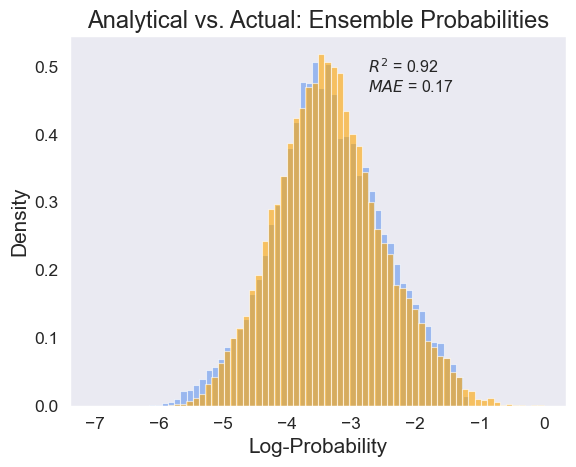

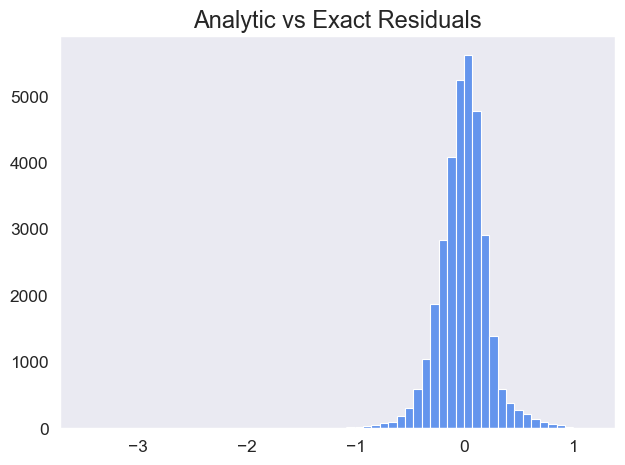

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error

# functions for simplicity
def lor(x): return 1.0 / (1.0 + np.square(x))
def sq(x):  return np.square(x)
def test_analytic_approximation():
    '''Tests the derived analytic approximation. 
    Applies linear regression to optimize the equation coefficient and constant.'''
    
    # # resonance approximation
    geometric_terms = a_dot**2 + (a * (1+a_dd**2)) 
    temporal_terms = - 1/(1+(1 + t)**2) - t
    phase_terms = 1/3*b*(g-k) + 1/3*(b**2+g**2+k**2)
    raw_shape = (geometric_terms + temporal_terms + phase_terms).reshape(-1,1)
    raw_shape = np.pi/4*(geometric_terms + temporal_terms + phase_terms + np.pi - 1/(2*np.pi*np.sqrt(n_dim))).reshape(-1,1) ### final result

    # linear refinement
    refiner = LinearRegression().fit(raw_shape, ups_kde)
    y_final = refiner.predict(raw_shape)
    
    # calculate scores
    r2 = r2_score(ups_kde, y_final)
    mae = mean_absolute_error(ups_kde, y_final)

    # final equation
    lin_coef = refiner.coef_[0][0]
    lin_int = refiner.intercept_[0]
    # ups_analytical = (raw_shape * lin_coef + lin_int).flatten() # use regression equation
    ups_analytical = raw_shape.flatten()
    
    # # result metrics
    residual = ups_kde.flatten() - ups_analytical
    r2 = r2_score(ups_kde, ups_analytical)
    mae = mean_absolute_error(ups_kde, ups_analytical)

    print(f'Refined equation: {lin_coef:.3f} (raw_shape) + {lin_int:.2f}')
    print(f'- R^2: {r2:.3f}')
    print(f'- MAE: {mae:.4f}')

    return ups_analytical, residual, r2, mae

### split data
ups_kde = df_physics['intensity'].copy().values.reshape(-1,1)
X_raw = encode_zeta(df_physics[zeta_order_si]) # min-maxed SI inputs
X_scaled = X_raw / np.array(bounds).max(axis=1) # using all variables

# map indices to variable names
t = X_scaled[:,0].flatten()
a = X_scaled[:,1].flatten()
a_dot = X_scaled[:,2].flatten()
a_dd = X_scaled[:,3].flatten()
m = X_scaled[:,6].flatten()
k = X_scaled[:,8].flatten()
b = X_scaled[:,9].flatten()
g = X_scaled[:,10].flatten()


### compare analytical to KDE resonances
print('Analytic approximation:')
ups_vals, res, r2, mae = test_analytic_approximation()

### plot
print()
# scatter of prediction vs analytic
# plt.scatter(ups_kde, ups_vals)
# plt.plot([ups_kde.min(),ups_kde.max()], [ups_kde.min(),ups_kde.max()], 'r--')
# plt.title('Analytic vs Exact Resonance')
# plt.xlabel('Exact')
# plt.ylabel('Analytic')
# plt.show()

# comparison plot
plt.hist(ups_kde-np.max(ups_vals),alpha=0.6,density=True,color='cornflowerblue',label='KDE',bins=60)
plt.hist(ups_vals-np.max(ups_vals),alpha=0.6,density=True,color='orange',label='Analytic',bins=60)
plt.title('Analytical vs. Actual: Ensemble Probabilities')
plt.xlabel('Log-Probability')
plt.ylabel('Density')
plt.text(0.6,0.85,f'$R^2$ = {r2:.2f}\n$MAE$ = {mae:.2f}', transform=plt.gca().transAxes)
# plt.savefig('plots/symbolic_comparison.png')
plt.show()

# residuals
plt.hist(res, color='cornflowerblue',bins=60)
plt.title('Analytic vs Exact Residuals')
plt.tight_layout()
plt.show()

## Big Bang Electromagnetic Injection
- Bias probabilities with external electromagnetic energy application.
- The result describes the number of particles created by the big bang (within 1% error).
- Particle creation $N(\zeta)$ resulting from 101 J/m^3 EM injection, expressed through each coordinate's spacetime volume normalized to a thermal wavepacket $\hat{V}_4$, change in probability $\Delta \ln P$, and uncertainty $\mathfrak{h}(\zeta)$:
$$N(\zeta) \propto \hat{V}_4 \exp \left( \frac{\Delta \ln P(\zeta \mid \Upsilon)}{\mathfrak{h}(\zeta)} \right)$$

Injecting inflaton-field energy density.

Initial probabilities: e^-1.1e+01 ± e^8.6e-01
Big bang probabilities: e^-9.9e+00 ± e^8.0e-01
Ratio: 2.3e+00


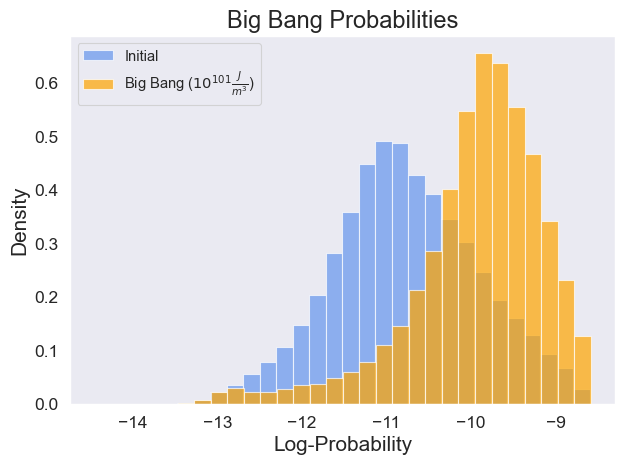


Average Macroscopic Entropy Shift (Delta S): 0.83
Unlocked Microstates ln(Omega_micro): 3.31e+00 ± 1.18e+00

Voxel Hypervolume: 10^117.07
Total Voxels: 10^118.53

Baseline Particles: 0.0
Derived Particles (Big Bang): 10^88.75 ± 10^0.91
Theoretical Expected: 10^89.41


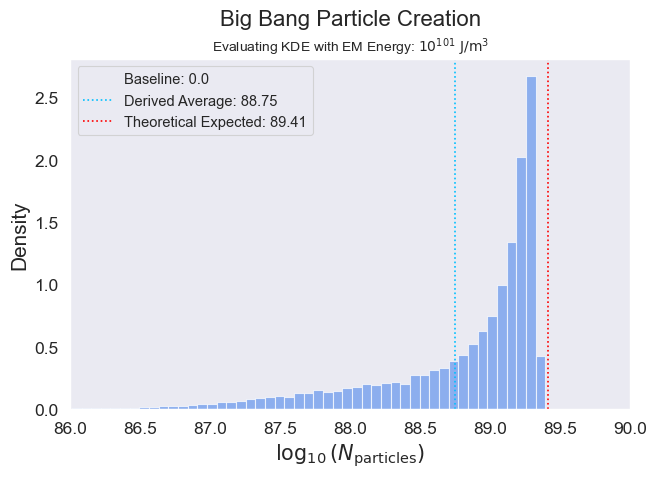

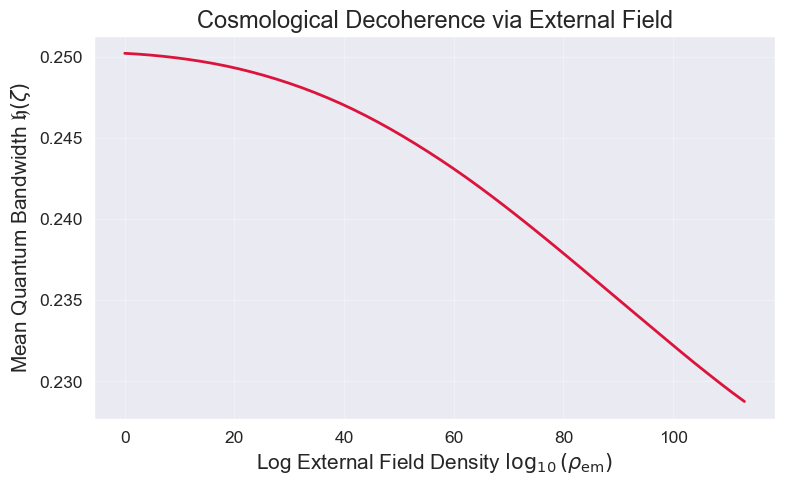

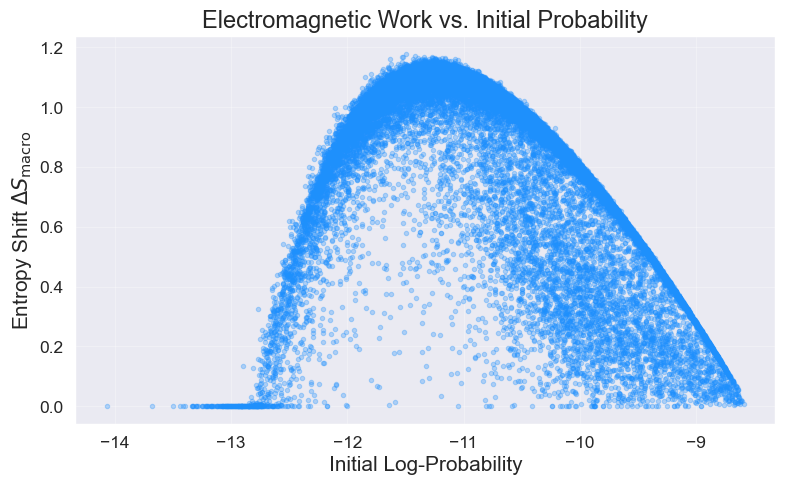


Entropy DECREASE with EM energy:


species
Exotic               236
Dark Energy           51
Negative Pressure      7
Name: count, dtype: int64

In [7]:
### re-evaluate resonant probabilities with inflaton-density EM-injection
print('Injecting inflaton-field energy density.')
inflaton_energy = 1e101
canonical_mask = (df_physics['regime']=='Canonical').values
big_bang_probs = analyze_coordinate(ensemble_exponents, rho_em=inflaton_energy)['probability'].values

# analysis
init_probs = df_physics['probability']
init_avg_prob = np.mean(init_probs.values)
init_stdev_prob = np.std(init_probs.values)
avg_prob = np.mean(big_bang_probs)
stdev_prob = np.std(big_bang_probs)
avg_ratio = avg_prob - init_avg_prob # logarithmic subtraction

print()
print(f'Initial probabilities: e^{init_avg_prob:.1e} ± e^{init_stdev_prob:.1e}')
print(f'Big bang probabilities: e^{avg_prob:.1e} ± e^{stdev_prob:.1e}')
print(f'Ratio: {np.exp(avg_ratio):.1e}')


### plot
plt.hist(init_probs, label='Initial', bins=30, color='cornflowerblue', density=True, alpha=0.7)
plt.hist(big_bang_probs, label=r'Big Bang ($10^{101} \frac{J}{m^3}$)', color='orange', bins=30, density=True, alpha=0.7)
plt.title('Big Bang Probabilities')
plt.xlabel('Log-Probability')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
# plt.savefig('big_bang_probs.png')
plt.show()



### calculate number of particles created
initial_ln_probs = df_physics['probability'].values
big_bang_ln_probs = big_bang_probs

# macroscopic entropy shift; delta (lnP)
delta_s_macro = big_bang_ln_probs - initial_ln_probs
canonical_mask = delta_s_macro>=0.0 # filter negative-entropy outliers for global results

# calculate local uncertainty
ensemble_si_vals = evaluate_ensemble(ensemble_exponents)
h_zeta = quantum_bandwidth(ensemble_si_vals['t_si'], ensemble_si_vals['action'], iso_params['W_zca'],norm_entropies)

# calculate unlocked degrees of freedom; ln(Omega_micro) = Delta S_macro / h_zeta
ln_omega_micro = delta_s_macro / h_zeta
avg_ln_density = np.mean(ln_omega_micro)
stdev_ln_density = np.std(ln_omega_micro)

# analysis
print(f'\nAverage Macroscopic Entropy Shift (Delta S): {np.mean(delta_s_macro):.2f}')
print(f'Unlocked Microstates ln(Omega_micro): {avg_ln_density:.2e} ± {stdev_ln_density:.2e}\n')


### calculate total particle yield
# normalize to planck units for dimensionless hypervolume
a_hat = 3 / l_planck # 3 meters at start of reheating
t_hat = 10**-32 / t_planck # 10^-32 seconds at start of reheating

# calculate thermal wavelengths --> substituting k_B*T with h_zeta
thermal_wavelengths = hbar*C_SI / h_zeta

# calculate dynamic wavepacket 3-volume (logarithmic, normalized to planck units)
vol_particle = 3 * np.log(thermal_wavelengths / l_planck)

# natural log of 4volume capacity
ln_4volume = 3 * np.log(a_hat) + np.log(t_hat)
ln_voxel_hypervol = np.mean(ln_4volume)

# calculate volumetric capacity (how many wavepackets fit in the 4-volume)
ln_capacity = ln_4volume - vol_particle
capacity = np.exp(ln_capacity)

# baseline (initial) state (# omega = 1, so (1 - 1) = 0 particles)
baseline_delta_s_macro = initial_ln_probs - initial_ln_probs
baseline_ln_omega_micro = baseline_delta_s_macro / h_zeta
baseline_omega_micro = np.exp(baseline_ln_omega_micro) # ground state (e^0 = 1)

# calculate baseline particles: (1 - 1) * capacity = 0
baseline_particles_array = (baseline_omega_micro - 1) * capacity
baseline_particles = np.mean(baseline_particles_array[canonical_mask])

# final (big bang) state
# calculate unlocked microstates and resulting particles
omega_micro = np.exp(ln_omega_micro)
final_particles = (omega_micro - 1) * capacity
ln_particles = np.log(np.maximum(final_particles, epsilon))
df_physics['ln_particles'] = ln_particles

# metrics for printing
avg_ln_n = np.mean(ln_particles[canonical_mask])
stdev_ln_n = np.std(ln_particles[canonical_mask])
log_theoretical_expected = 89.41
ln_voxels = ln_omega_micro + ln_4volume # total voxels (unlocked microstates * volume)
ln_num_voxels = np.mean(ln_voxels[canonical_mask])

### analysis
print(f'Voxel Hypervolume: 10^{ln_voxel_hypervol / np.log(10):.2f}')
print(f'Total Voxels: 10^{ln_num_voxels / np.log(10):.2f}\n')
print(f'Baseline Particles: {baseline_particles}') 
print(f'Derived Particles (Big Bang): 10^{avg_ln_n / np.log(10):.2f} ± 10^{stdev_ln_n / np.log(10):.2f}')
print(f'Theoretical Expected: 10^{log_theoretical_expected:.2f}')

### plot
plt.figure(figsize=(8, 5))

plt.hist(ln_particles[canonical_mask] / np.log(10), bins=200, density=True, alpha=0.7, color='cornflowerblue')
plt.axvline(x=log_theoretical_expected, color='red', alpha=0, linestyle=':', label=f'Baseline: 0.0')
plt.axvline(x=avg_ln_n / np.log(10), color='deepskyblue', linestyle=':', label=f'Derived Average: {avg_ln_n / np.log(10):.2f}')
plt.axvline(x=log_theoretical_expected, color='red', linestyle=':', label=f'Theoretical Expected: {log_theoretical_expected:.2f}')
plt.suptitle('Big Bang Particle Creation', y=0.95, fontsize=16)
plt.title(r'Evaluating KDE with EM Energy: $10^{101} \ \text{J}/\text{m}^3$',fontsize=10)
plt.xlabel(r'$\log_{10}(N_{\mathrm{particles}})$')
plt.ylabel('Density')
plt.legend()
plt.xlim([86,90])

plt.subplots_adjust(top=0.85, bottom=0.15, left=0.15, right=0.85)
# plt.savefig('particle_creation.png', bbox_inches='tight')
plt.show()

### plot uncertainty 
rho_sweep = np.logspace(0, 113, 50)
mean_h_values = []
for rho in rho_sweep:
    # calculate bandwidth for each field strength
    pulsed_si_vals = evaluate_ensemble(ensemble_exponents, rho_em=rho)
    h_temp = quantum_bandwidth(pulsed_si_vals['t_si'], pulsed_si_vals['action'], iso_params['W_zca'], norm_entropies)
    mean_h_values.append(np.mean(h_temp))

plt.figure(figsize=(8, 5))
plt.plot(np.log10(rho_sweep), mean_h_values, color='crimson', lw=2)
plt.title('Cosmological Decoherence via External Field')
plt.xlabel(r'Log External Field Density $\log_{10}(\rho_{\mathrm{em}})$')
plt.ylabel(r'Mean Quantum Bandwidth $\mathfrak{h}(\zeta)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### scatter of thermodynamic work
plt.figure(figsize=(8, 5))
plt.scatter(initial_ln_probs[canonical_mask], delta_s_macro[canonical_mask], alpha=0.3, color='dodgerblue', s=10)
plt.title('Electromagnetic Work vs. Initial Probability')
plt.xlabel('Initial Log-Probability')
plt.ylabel(r'Entropy Shift $\Delta S_{\mathrm{macro}}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### entropy decrease 
test_mask = delta_s_macro<0
print('\nEntropy DECREASE with EM energy:')
display(df_physics.iloc[test_mask]['species'].value_counts())

### Iterating through EM densities

Injecting inflaton-field energy density.


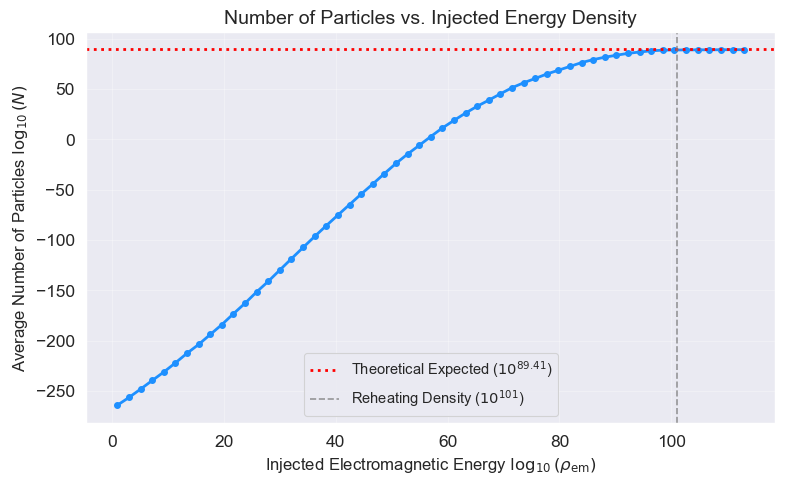

In [12]:
### re-evaluate resonant probabilities with inflaton-density EM-injection
print('Injecting inflaton-field energy density.')
avg_particles = []
em_exponents = np.linspace(1, 113, 55)
for i in em_exponents:
    working_df = df_physics.copy()
    canonical_mask = (working_df['regime']=='Canonical').values
    big_bang_probs = analyze_coordinate(ensemble_exponents, rho_em=10**i)['probability'].values
    
    # analysis
    init_probs = working_df['probability']
    init_avg_prob = np.mean(init_probs.values)
    init_stdev_prob = np.std(init_probs.values)
    avg_prob = np.mean(big_bang_probs)
    stdev_prob = np.std(big_bang_probs)
    avg_ratio = avg_prob - init_avg_prob # logarithmic subtraction
    
    
    ### calculate number of particles created
    initial_ln_probs = working_df['probability'].values
    big_bang_ln_probs = big_bang_probs
    
    # macroscopic entropy shift; delta (lnP)
    delta_s_macro = big_bang_ln_probs - initial_ln_probs
    positive_entropy_mask = delta_s_macro>=0.0 # filter negative-entropy outliers for global results
    
    # calculate local uncertainty
    ensemble_si_vals = evaluate_ensemble(ensemble_exponents)
    h_zeta = quantum_bandwidth(ensemble_si_vals['t_si'], ensemble_si_vals['action'], iso_params['W_zca'],norm_entropies)
    
    # calculate unlocked degrees of freedom; ln(Omega_micro) = Delta S_macro / h_zeta
    ln_omega_micro = delta_s_macro / h_zeta
    avg_ln_density = np.mean(ln_omega_micro)
    stdev_ln_density = np.std(ln_omega_micro)
    

    ### calculate total particle yield
    # normalize to planck units for dimensionless hypervolume
    a_hat = 3 / l_planck # 3 meters at start of reheating
    t_hat = 10**-32 / t_planck # 10^-32 seconds at start of reheating
    
    # calculate thermal wavelengths --> substituting k_B*T with h_zeta
    thermal_wavelengths = hbar*C_SI / h_zeta
    
    # calculate dynamic wavepacket 3-volume (logarithmic, normalized to planck units)
    vol_particle = 3 * np.log(thermal_wavelengths / l_planck)
    
    # natural log of 4volume capacity
    ln_4volume = 3 * np.log(a_hat) + np.log(t_hat)
    ln_voxel_hypervol = np.mean(ln_4volume)
    
    # calculate volumetric capacity (how many wavepackets fit in the 4-volume)
    ln_capacity = ln_4volume - vol_particle
    capacity = np.exp(ln_capacity)
    
    # baseline (initial) state (# omega = 1, so (1 - 1) = 0 particles)
    baseline_delta_s_macro = initial_ln_probs - initial_ln_probs
    baseline_ln_omega_micro = baseline_delta_s_macro / h_zeta
    baseline_omega_micro = np.exp(baseline_ln_omega_micro) # ground state (e^0 = 1)
    
    # calculate baseline particles: (1 - 1) * capacity = 0
    baseline_particles_array = (baseline_omega_micro - 1) * capacity
    baseline_particles = np.mean(baseline_particles_array[positive_entropy_mask])
    
    # final (big bang) state
    # calculate unlocked microstates and resulting particles
    omega_micro = np.exp(ln_omega_micro)
    final_particles = (omega_micro - 1) * capacity
    ln_particles = np.log(np.maximum(final_particles, epsilon))
    working_df['ln_particles'] = ln_particles
    
    # metrics for printing
    avg_ln_n = np.mean(ln_particles[positive_entropy_mask])
    stdev_ln_n = np.std(ln_particles[positive_entropy_mask])

    # convert natural ln to base 10
    avg_particles.append(avg_ln_n / np.log(10))

# plot
plt.figure(figsize=(8, 5))
plt.plot(em_exponents, avg_particles, marker='o', markersize=4, color='dodgerblue', lw=2)

plt.axhline(y=89.41, color='red', linestyle=':', lw=2, label='Theoretical Expected ($10^{89.41}$)')
plt.axvline(x=101, color='gray', linestyle='--', alpha=0.8, label=r'Reheating Density ($10^{101}$)')

plt.title('Number of Particles vs. Injected Energy Density', fontsize=14)
plt.xlabel(r'Injected Electromagnetic Energy $\log_{10}(\rho_{\mathrm{em}})$', fontsize=12)
plt.ylabel(r'Average Number of Particles $\log_{10}(N)$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('particles_vs_em.png')
plt.show()

#### Trajectory of current universe

zeta_universe (SI): [[ 4.35000000e+17  4.40000000e+26  9.98800000e+08  1.21299266e-09
   1.31628796e-07  4.80456039e+03 -9.56051780e+14  1.00000000e-40
   0.00000000e+00  1.00000000e+00  1.00000000e+00]]
Evolving current universe.
Evaluating topographic trajectory.
Progress: 0% (dt = 0.001)
Progress: 10% (dt = 0.001)
Progress: 20% (dt = 0.001)
Progress: 30% (dt = 0.001)
Progress: 40% (dt = 0.001)
Progress: 50% (dt = 0.001)
Progress: 60% (dt = 0.001)
Progress: 70% (dt = 0.001)
Progress: 80% (dt = 0.001)
Progress: 90% (dt = 0.001)


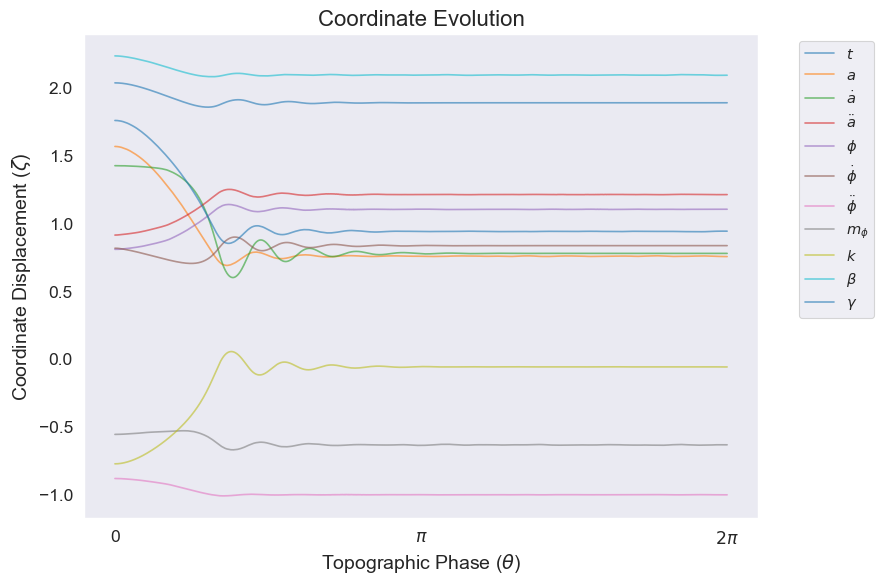

In [13]:
### building the observable universe
kappa_si = 2.076e-43
C_SI = 299792458.0
hbar = 1.0545718e-34

H_today = 2.27e-18       
Omega_L = 0.69           
Omega_m = 0.31           
a_today = 4.4e26

### initialize coordinate
# geometric parameters
zeta_universe_si = np.zeros((1, 11))
zeta_universe_si[0, 0] = 4.35e17                             
zeta_universe_si[0, 1] = a_today                             
zeta_universe_si[0, 2] = H_today * a_today                   
zeta_universe_si[0, 3] = (H_today**2) * (Omega_L - 0.5 * Omega_m) * a_today 
zeta_universe_si[0, 8] = 0.0                                 
zeta_universe_si[0, 9] = 1.0                                 
zeta_universe_si[0, 10] = 1.0                                

### scalar field parameters
rho_crit = (3.0 * H_today**2) / (kappa_si * C_SI**2)
rho_kinetic = 0.155 * rho_crit   
rho_potential = 0.845 * rho_crit 

approx_mass = 1e-40
mu_sq = (approx_mass * (C_SI / hbar))**2

phi_required = np.sqrt(2.0 * rho_potential / (zeta_universe_si[0, 10] * mu_sq))
phidot_required = np.sqrt(2.0 * rho_kinetic * (C_SI**2) / zeta_universe_si[0, 9])

zeta_universe_si[0, 4] = phi_required 
zeta_universe_si[0, 5] = phidot_required
zeta_universe_si[0, 7] = approx_mass  

kg_rhs_val = - (C_SI**2) * zeta_universe_si[0, 10] * mu_sq * phi_required
zeta_universe_si[0, 6] = (kg_rhs_val / zeta_universe_si[0, 9]) - (3.0 * H_today * phidot_required)

print(f'zeta_universe (SI): {zeta_universe_si}')
### analyze trajectory
zeta_universe_encoded = encode_zeta(zeta_universe_si)

print('Evolving current universe.')
time_history, iso_trajectory, iso_velocities = topographic_evolution(
    zeta_universe_encoded, 
    analytic=False,
    verbose=True,
    initial_dt=1e-3,
    tolerance=1e-2,
    t_max=2*np.pi
)

### Appendix validations (post-hoc)

Occupancy: 0.289 ± 0.001121
Differential Entropy: 99.82% ± 0.0591%
Occupancy: 0.293 ± 0.001129
Differential Entropy: 48.13% ± 28.9821%


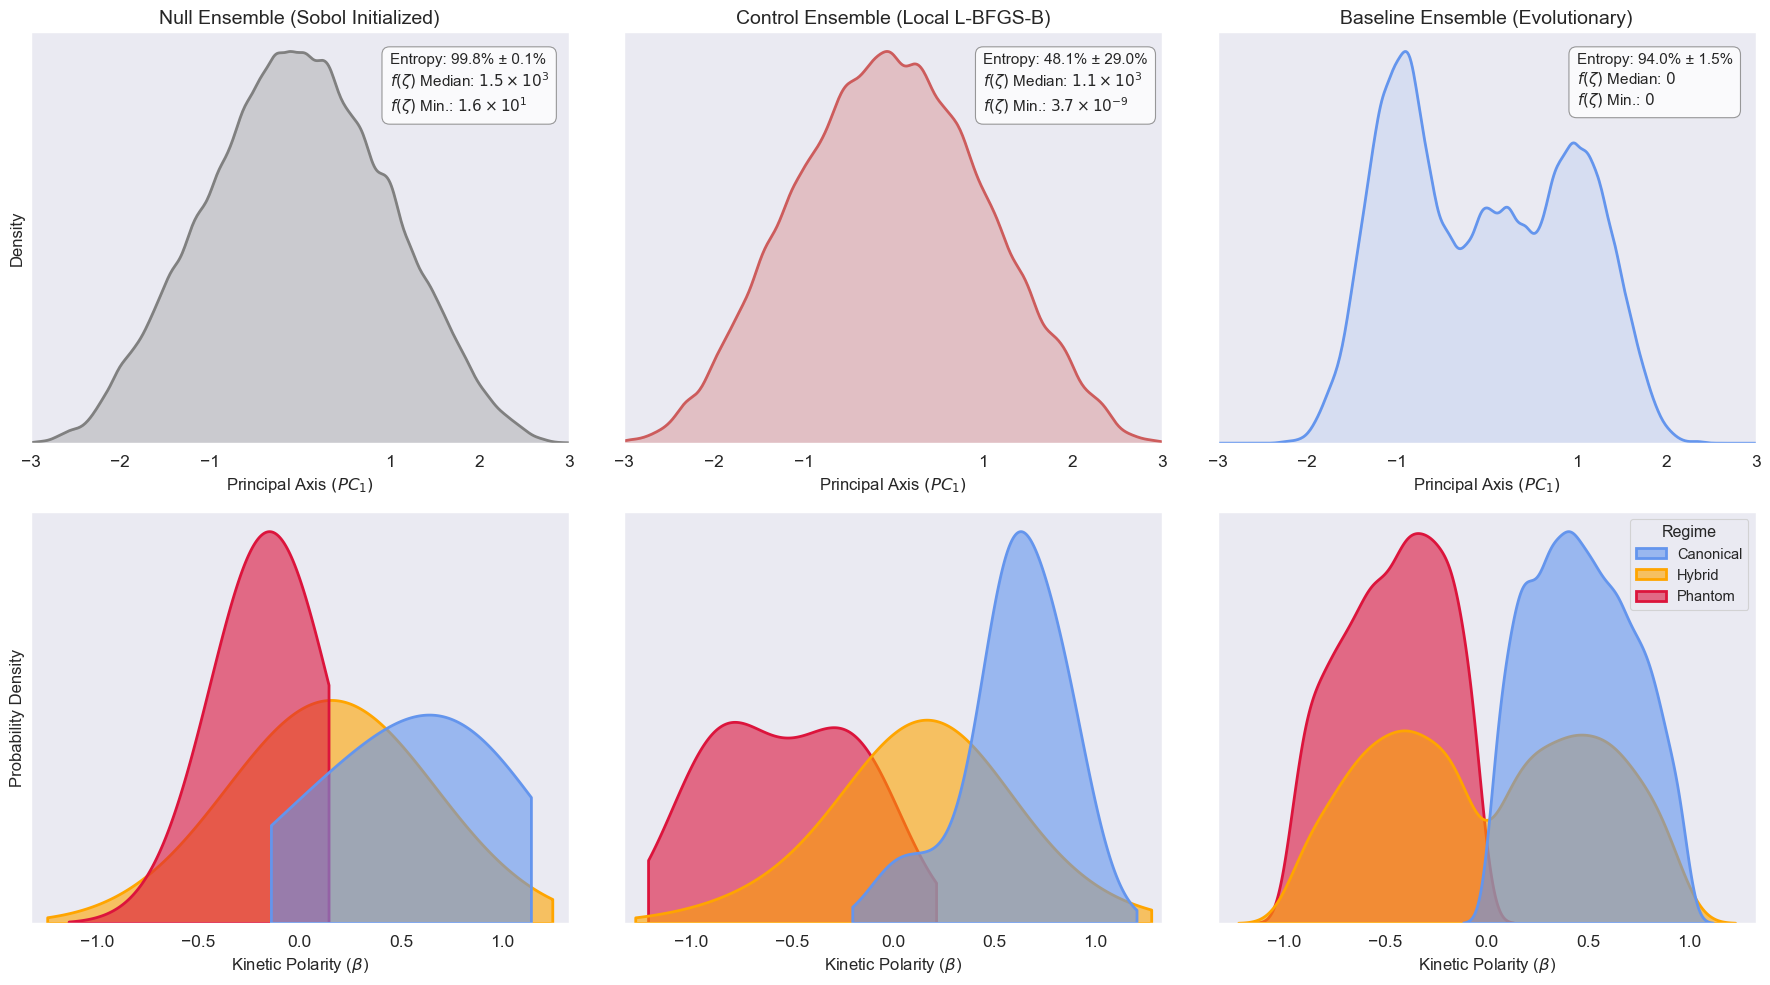

In [30]:
# baseline data (fresh load)
baseline_ensemble = ensemble_exponents.copy()
ensemble_baseline = pd.read_csv('spacetime_ensemble.csv')
ensemble_baseline = ensemble_baseline.drop_duplicates()
ensemble_baseline = ensemble_baseline[ensemble_baseline['fitness'] <= hbar/2]
baseline_residuals = ensemble_baseline['fitness']
local_seed = int(1e6) # generate with an unused seed
N_samples = 33131

### null ensemble
null_ensemble = hdim.uniform(n_samples=N_samples, bounds=bounds, method='sobol', seed=local_seed)
null_residuals = np.array([obj_func(x, evolution=True) for x in null_ensemble]) # evolution = True to match minimization

### control ensemble (local minimization)
print('Generating control ensemble.')
control_ensemble = []
control_residuals = []
for i in range(len(null_ensemble)):
    initial_point = null_ensemble[i]
    
    # minimize via L-BFGS-B
    sol, fit = hdim.minimize(
        func=obj_func, 
        bounds=bounds, 
        args=(True,),
        init=initial_point, 
        method='L-BFGS-B',
        verbose=False,
    )
    control_ensemble.append(sol)
    control_residuals.append(fit)

### preprocess and transform
control_ensemble = np.array(control_ensemble)
control_residuals = np.array(control_residuals)

# SI vals
null_si = evaluate_ensemble(null_ensemble)
control_si = evaluate_ensemble(control_ensemble)


# isotropize ensembles
null_iso, null_iso_metrics = hdim.isotropize(pd.DataFrame(null_ensemble))
control_iso, control_iso_metrics = hdim.isotropize(pd.DataFrame(control_ensemble))

# PCA
null_iso_1d = pca1d.transform(null_iso)
control_iso_1d = pca1d.transform(control_iso)
baseline_iso_1d = pca1d.transform(ensemble_iso.copy())

### bandwidths
# null whitening metrics
null_diversity_results = diversity_statistics(pd.DataFrame(null_ensemble),verbose=False) # run before KDE to feed entropy into bandwidths
null_norm_entropies = null_diversity_results['diff_entropies']
null_W_matrix = null_iso_metrics['W_zca']
null_sigma_q = quantum_bandwidth(null_si['t_si'],null_si['action'],W_matrix=null_W_matrix, norm_entropies=null_norm_entropies)


# control whitening metrics
control_diversity_results = diversity_statistics(pd.DataFrame(control_ensemble),verbose=False) # run before KDE to feed entropy into bandwidths
control_norm_entropies = control_diversity_results['diff_entropies']
control_W_matrix = control_iso_metrics['W_zca']
control_sigma_q = quantum_bandwidth(control_si['t_si'],control_si['action'],W_matrix=control_W_matrix, norm_entropies=control_norm_entropies)




# shared x_range for KDE evaluation
plot_points_1d = 2**17 if plot_resolution == 'high' else 2**9
x_range = np.linspace(-3.5, 3.5, plot_points_1d).reshape(-1, 1)


# Lorentzian KDE for all three datasets
# null KDE
log_P_null = hdim.lorentzian(x_range, null_sigma_q, null_iso_1d, eff_dim=11, estimator='pointwise', verbose=False)
prob_null = np.exp(log_P_null)
prob_null /= np.max(prob_null) # normalize

# control KDE
log_P_control = hdim.lorentzian(x_range, control_sigma_q, control_iso_1d, eff_dim=11, estimator='pointwise', verbose=False)
prob_control = np.exp(log_P_control)
prob_control /= np.max(prob_control) # normalize

# baseline KDE (matches initial ensemble)
log_P_base = hdim.lorentzian(x_range, sigma_q_ensemble, baseline_iso_1d, eff_dim=11, estimator='pointwise', verbose=False)
prob_base = np.exp(log_P_base)
prob_base /= np.max(prob_base) # normalize


# helper to format stats
def format_stats(residuals, entropies):
    def to_latex_sci(val):
        if val == 0:
            return '0'
        sci_str = f'{val:.1e}' # scientific notation
        leading_val, exponent = sci_str.split('e') # split by e
        exponent = int(exponent) # take exponent
        
        # if leading_val is exactly 1.0, return 10^X
        if leading_val == '1.0':
            return f'10^{{{exponent}}}'
        
        # otherwise val * exponent
        return f'{leading_val} \\times 10^{{{exponent}}}'

    # Calculate mean and standard error for entropy
    avg_entropy = np.mean(entropies)
    se_entropy = np.std(entropies, ddof=1) / np.sqrt(len(entropies))
    entropy_str = f"{avg_entropy:.1%} ± {se_entropy:.1%}"

    # median and min objective values
    med_val = np.median(residuals)
    min_val = np.min(residuals)
    med_str = to_latex_sci(med_val)
    min_str = to_latex_sci(min_val)
    
    # render as latex notation
    return f'Entropy: {entropy_str}\n$f(\zeta)$ Median: ${med_str}$\n$f(\zeta)$ Min.: ${min_str}$'

### compute stats strings for plot text boxes
stats_null = format_stats(null_residuals, null_norm_entropies)
stats_control = format_stats(control_residuals, control_norm_entropies)
stats_base = format_stats(baseline_residuals, norm_entropies)

### regime distribution dataframes
df_null = analyze_coordinate(null_ensemble)
df_null['probability'] = np.exp(df_null['probability'])
df_null.rename(columns={'regime':'Regime'}, inplace=True)

df_control = analyze_coordinate(control_ensemble)
df_control['probability'] = np.exp(df_control['probability'])
df_control.rename(columns={'regime':'Regime'}, inplace=True)

df_baseline = analyze_coordinate(baseline_ensemble)
df_baseline['probability'] = np.exp(df_baseline['probability'])
df_baseline.rename(columns={'regime':'Regime'}, inplace=True)


### plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# text box parameters
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
palette = {'Canonical': 'cornflowerblue', 'Phantom': 'crimson', 'Hybrid': 'orange'}

### row 0: probability density projection
# null density
axes[0, 0].plot(x_range.flatten(), prob_null, color='gray', lw=2)
axes[0, 0].fill_between(x_range.flatten(), prob_null, color='gray', alpha=0.3)
axes[0, 0].set_title('Null Ensemble (Sobol Initialized)', fontsize=14)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].text(0.667, 0.95, stats_null, transform=axes[0, 0].transAxes, 
             fontsize=11, verticalalignment='top', bbox=props)

# control density
axes[0, 1].plot(x_range.flatten(), prob_control, color='indianred', lw=2)
axes[0, 1].fill_between(x_range.flatten(), prob_control, color='indianred', alpha=0.3)
axes[0, 1].set_title('Control Ensemble (Local L-BFGS-B)', fontsize=14)
axes[0, 1].text(0.667, 0.95, stats_control, transform=axes[0, 1].transAxes, 
             fontsize=11, verticalalignment='top', bbox=props)

# baseline density
axes[0, 2].plot(x_range.flatten(), prob_base, color='cornflowerblue', lw=2)
axes[0, 2].fill_between(x_range.flatten(), prob_base, color='cornflowerblue', alpha=0.15)
axes[0, 2].set_title('Baseline Ensemble (Evolutionary)', fontsize=14)
axes[0, 2].text(0.667, 0.95, stats_base, transform=axes[0, 2].transAxes, 
             fontsize=11, verticalalignment='top', bbox=props)

# formatting row 0
for ax in axes[0, :]:
    ax.set_xticks([-3, -2, -1, 1, 2, 3])
    ax.set_xlim(-3, 3)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([]) 
    ax.set_xlabel(r'Principal Axis $(PC_1)$', fontsize=12)


### row 2: energy phase structure
dfs = [df_null, df_control, df_baseline]

for i, df in enumerate(dfs):
    sns.kdeplot(
        data=df, 
        x='beta', 
        weights=np.abs(df['probability']), 
        hue='Regime', 
        ax=axes[1, i], 
        fill=True,
        alpha=0.6, 
        palette=palette, 
        linewidth=2,
        common_norm=False, 
        cut=3, 
        gridsize=1000, 
        legend=(i == 2) # only show legend on the last plot
    )

    # labels
    axes[1, i].set_xlim(-1.33, 1.33)
    axes[1, i].set_xlabel(r'Kinetic Polarity ($\beta$)', fontsize=12)
    axes[1, i].set_yticks([]) 
    if i == 0:
        axes[1, i].set_ylabel('Probability Density', fontsize=12)
    else:
        axes[1, i].set_ylabel('')

# save plot
plt.tight_layout()
plt.savefig('panel.png', dpi=300)
plt.show()

In [20]:
np.mean(null_norm_entropies)

np.float64(0.9981590897614783)